<a href="https://colab.research.google.com/github/gsferreira-tec/vcomp/blob/main/assignment_2/Copy_of_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Alt-text](https://www.up.pt/portal/media/images/feup.original.format-png.png)

# **FEUP - Master's in Electrical and Computer Engineering**
## **Computer Vision - Assignment 2**

###This document is the second assignment of the Computer Vision course unit of the Master's in Electrical and Computer Engineering of the Faculty of Engineering of the University of Porto.

###In this second assignment, groups of two or three students were asked to choose a project out of a list and develop it using PyTorch - the chosen project theme was "**Classification of defects in photovoltaic modules**".

# **Authors**
* Guilherme Sousa Ferreira (up201706719@fe.up.pt)
* Diogo Loayza Duarte (up202107314@up.pt)
* Nuno Pinho (up201805224@up.pt)

# **Table of contents**

*   [Introduction](#introduction)


*   [Objectives of the assignment](#objectives)
*   [Implementation](#implementation)

    - [Kickstart - Data Exploration, pre-processing and augmentation](#kickstart)
    - [Task 1 - Building a custom CNN](#t1)
    - [Task 2 - Deeper dive on the data augmentation techinques applied to the images in this datase](#t2)    
    - [Task 3 - Implementation of at least 1 existing model (e.g., MobileNet, VGG, EfficientNet and ResNet) and comparison with the custom CNN](#t3)
    - [Task 4 - Discussion of Results in Light of Reference [2]](#t4)

*   [Conclusion](#conclusion)

*   [References](#references)


## **Introduction** <a name="introduction"></a>

Given the recent events regarding failures with the solar farm infrastructure leading to significant consequences in Portugal and Spain, pre-emptive failure detection has become of paramount importance. Throughout this project we aim to implement a classifier of photovoltaic (PV) anomalies/defects using deep learning techniques to tackle the problem of anomaly detection in these PV farms without requiring the intervention of experts in this kind of detection in the field.

## **Objectives of the assignment** <a name="objectives"></a>


For the chosen assignment, 4 main requirements were demanded. Transcribing the worksheet itself, they were:


###"**1. Develop three AI-models to evaluate the status of the PV module using thermal signatures including:**
 - **(a)** Model 1: Binary classification (anomaly or no-anomaly);
 - **(b)** Model 2: Classification with 11 anomaly classes (cell, cell-multi, cracking, hotspot, hot-spot-multi, shadowing, diode, diode-multi, vegetation, soiling and offline module)
 - **(c)** Model 3: Classification with 12 classes (cell, cell-multi, cracking, hot-spot, hotspot-multi, shadowing, diode, diode-multi, vegetation, soiling, offline-module and no-anomaly).
###**2. Describe data augmentation techniques that were used.**
###**3. Compare the results of your AI-model with at least 1 existing models (e.g., MobileNet,VGG, EfficientNet and ResNet). Use the following metrics to assess the quality of your implementation:**
 - Accuracy (%) and F1-Score (%) of training and testing;
 - Confusion matrix;
 - Model complexity (# parameters).
###**4. Discuss the results, taking into consideration the following paper:**
https://www.sciencedirect.com/science/article/pii/S0196890424006599"




# **Implementation**  <a name="implementation"></a>

 All the required implementations will follow in the rest of the document. The code will be divided in sections - all the sections will correspond to the numbers of the requirements specified in the worksheet, in order. Before them, there will be a section called "**Kickstart**", where the data exploratory analysis, pre-processing and augmentation will be. This introductory step is pivotal to the rest of the project.

# **Kickstart** - Data Exploration, Pre-processing and augmentation <a name="kickstart"></a>

# **Download and Unzip Data from a URL**
First download a zip file containing the data and labels from a specified URL and then unzip its contents.

In [ ]:
# URL of the zip file containing data and labels
zip_url = 'https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip'

# Extract filename from URL
zip_filename = zip_url.split('/')[-1]

# Define output filenames after unzipping
img_dir = 'InfraredSolarModules/images'
labels_filename = 'InfraredSolarModules/module_metadata.json'

# just an upgrade because I got the notice...
!pip install --upgrade pip

# Download the zip file
!wget -O "{zip_filename}" "{zip_url}"

# Unzip the file to the current directory
!unzip -o "{zip_filename}" -d "."

print(f"Downloaded and unzipped {zip_filename}. Expecting image data in '{img_dir}' and labels in '{labels_filename}'.")

Streaming output truncated to the last 5000 lines.
  inflating: ./InfraredSolarModules/images/11778.jpg  
  inflating: ./InfraredSolarModules/images/5896.jpg  
  inflating: ./InfraredSolarModules/images/4550.jpg  
  inflating: ./InfraredSolarModules/images/19324.jpg  
  inflating: ./InfraredSolarModules/images/16017.jpg  
  inflating: ./InfraredSolarModules/images/10472.jpg  
  inflating: ./InfraredSolarModules/images/2135.jpg  
  inflating: ./InfraredSolarModules/images/4.jpg  
  inflating: ./InfraredSolarModules/images/5882.jpg  
  inflating: ./InfraredSolarModules/images/19330.jpg  
  inflating: ./InfraredSolarModules/images/4544.jpg  
  inflating: ./InfraredSolarModules/images/16003.jpg  
  inflating: ./InfraredSolarModules/images/12265.jpg  
  inflating: ./InfraredSolarModules/images/9060.jpg  
  inflating: ./InfraredSolarModules/images/14614.jpg  
  inflating: ./InfraredSolarModules/images/6353.jpg  
  inflating: ./InfraredSolarModules/images/9706.jpg  
  inflating: ./InfraredSol

# **Importing the Necessary Libraries**

In [ ]:
# just trying a fix for AMD GPUs
import os
# os.environ["TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL"] = "1"
# os.environ["TORCH_ENABLE_FLASH_SDP"] = "0"
# os.environ["TORCH_ENABLE_MEM_EFFICIENT_SDP"] = "O"
# os.environ["TORCH_ENABLE_MATH_SDP"] = "1"
%env  TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1
import torch
print("AMD Safety overrides have been successfully applied.")

env: TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1
AMD Safety overrides have been successfully applied.


In [ ]:
import pandas as pd
from PIL import Image, ImageFilter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# import torchvision.transforms as T
import albumentations as A # as alternative to torch.transforms does somethings automatically to the masks
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from torchvision.models import (
    vit_b_16, ViT_B_16_Weights,
    vgg16, VGG16_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)
import torch.optim as optim
import time
from tqdm import tqdm
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import torch.nn.functional as F
import gc
import cv2

# **Splitting the Data**

- Having as reference the split made by the authors of the paper in [1] we decided to go with the same split: 80/10/10 for training/validation/testing.

In [ ]:
# read the classes from the metadata from json file
json_path = 'InfraredSolarModules/module_metadata.json'
full_df = pd.read_json(json_path, orient='index')

# Global class-to-index maps (computed once, used everywhere)
_DEFECT_CLASSES_11 = sorted(
    full_df[full_df['anomaly_class'].str.lower() != 'no-anomaly']['anomaly_class'].unique()
)
_ALL_CLASSES_12 = sorted(full_df['anomaly_class'].unique())
CLASS_TO_IDX_11 = {c: i for i, c in enumerate(_DEFECT_CLASSES_11)}
CLASS_TO_IDX_12 = {c: i for i, c in enumerate(_ALL_CLASSES_12)}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# split the dataset into 80/10/10 for train/validate/test
train_df, temp_df = train_test_split(
    full_df, test_size=0.2, random_state=SEED, stratify=full_df['anomaly_class']
)

# here it is already split 80/20 so we split in half hence the test_size=0.5
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['anomaly_class']
)

print(f"Dataset Split -> Test: {len(test_df)} | Train: {len(train_df)} | Validation: {len(val_df)}")

Dataset Split -> Test: 2000 | Train: 16000 | Validation: 2000


# **Preprocessing of the images with Sharpening Filter**

- The preprocessing step applies an **Unsharp Mask** filter to sharpen structural boundaries and enhance high-frequency spatial details across the dataset. In infrared and thermal imaging of photovoltaic modules, critical defects—such as subtle micro-cracks, localized cell hot spots, or dust accumulation—often manifest as soft, low-contrast thermal gradients that can easily be overlooked or smoothed out during neural network downsampling. By boosting edge contrast, this sharpening operation makes fine-grained boundaries and thermal transitions more pronounced, allowing the vision backbone to extract high-fidelity geometric features and better differentiate between normal operating conditions and complex, minor defect variations.

In [ ]:
orig_dir = 'InfraredSolarModules/images'
sharp_dir = 'InfraredSolarModules/sharpened_images'
os.makedirs(sharp_dir, exist_ok=True)

print("Applying the Unsharp Mask for all images beforehand...")

all_images = full_df['image_filepath'].tolist()

for img_name in tqdm(all_images):
    base_name = os.path.basename(img_name)
    orig_path = os.path.join(orig_dir, base_name)
    new_path = os.path.join(sharp_dir, base_name)

    if not os.path.exists(new_path):
        img = Image.open(orig_path).convert('RGB')
        img = img.filter(ImageFilter.UnsharpMask(radius=2, percent=150))
        img.save(new_path)

print("Image pre-processing complete.")

Applying the Unsharp Mask for all images beforehand...


100%|██████████| 20000/20000 [00:00<00:00, 302077.73it/s]

Image pre-processing complete.


# **Dataset Exploration**
- It can be seen, below, that the data is labelled with 12 different classes - 1 of which corresponds to pictures of photovoltaic modules in a good state (this class is labelled 'No-Anomaly') and all the others correspond to classes that represent photovoltaic modules with some type of anomaly.
- All the images that belong to the classes representative of photovoltaic modules with anomalies sum to 10000, which is the same amount of images in the 'No-Anomaly' class.
- However, inbetween these anomalous classes, there is a big discrepancy of data: there are classes with around 1000 samples while there are others with around 200 samples.
- This was presumed to cause problems, moreso in the models that needed to make the 11 and 12 classes classification - the models will never fit well enough to distinguish properly the undersampled classes, as they have few examples to get their intricansies compared to the others. There are some approaches to take in this type of situation to help mitigate this problem, however, they can only go so far as all of them have some caveat - for example:
  - The data could be augmented artificially, but, applying too many augmentations will not serve the models' real life application as they won't capture such images in real-time. Also, replicating too many images with a decent amount of augmentations will make it so that there will be a lot of images similar to each other, which is prone to increase overfitting;
  - During training, the data could be sampled in a way such that more images from the underrepresented classes are fed to the model, however, this is very prone to overfitting, as eventually there won't be new images from the underrepresented classes to acompany the ammount of the (by-comparison) overrepresented.
  - Artificially generated data (with generative AI) could be added in order to fill the undersampled classes so that they would be as closely represented as possible to the most represented classes - this would probably be the best way to deal with this problem, but it also has the problem that the generated images are not good enough representations of the real images;
  - Cutting data from the most represented classes could also be an option, but this will make the model worse on detecting such classes.

  Out of the aforementioned approaches, a combination of the first two was taken - this will be more explored furtherly, when its implementation in the document arrives.

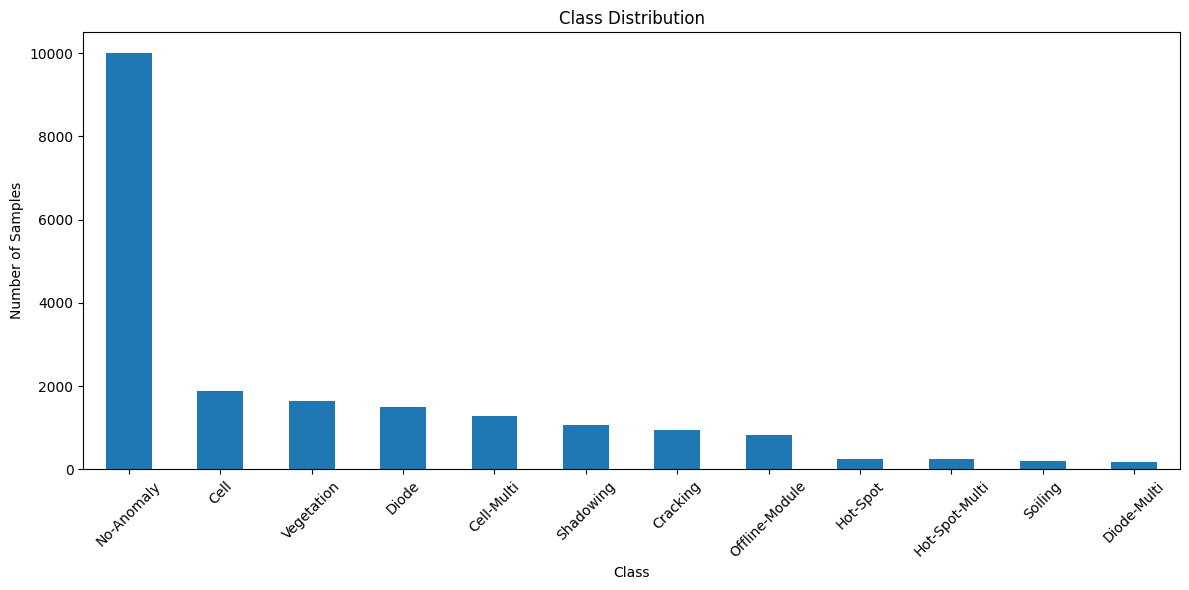

anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
Name: count, dtype: int64
The number of samples of images with No Anomalies:  10000
The number of samples of images with Anomalies:  10000


In [ ]:
class_counts = full_df['anomaly_class'].value_counts()

plt.figure(figsize=(12,6))
class_counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(class_counts)


print("The number of samples of images with No Anomalies: ", class_counts['No-Anomaly'])
print("The number of samples of images with Anomalies: ", class_counts.drop("No-Anomaly").sum())



The dataset has 12 distinct classes, 11 of which represented photovoltaic modules with different types of defects and the other represented photovoltaic modules with no anomalies. Given that the project specifications required the implementation of 3 models for 3 different tasks - one to distinguish the pictures with an anomaly from the pictures with no anomalies, one to distinguish the anomalies themselves and one to distinguish all the 12 classes - a function to build the dataset with the labels according to the task was implemented.

---

# **Label Mapping & Dataset Build**

- In the code cell below we build the dataframe mapping the different images to the respective classes according to the task that is set to be performed.
- For binary we have only 2 labels `Anomaly` and  `No-Anomaly`.
- For the 11-class multi-classification problem we have 11 different labels names corresponding to the type of anomaly.
- For the 12-class task we have the previous 11-classes plus the `No-Anomaly` class.   

After that we build the custom dataset class, `PVDataset`, which allows for more flexibility and reusability between classification tasks as it provides

In [ ]:
# helper function to build the dataset according to the task at hand
def build_dataframe(config, full_df):
    df = full_df.copy()
    task = config['task']

    if task == 'binary':
        df['label'] = df['anomaly_class'].str.lower().apply(lambda x: 0 if x == 'no-anomaly' else 1)

    elif task == 'multi_11':
        df = df[df['anomaly_class'].str.lower() != 'no-anomaly'].copy()
        df['label'] = df['anomaly_class'].map(CLASS_TO_IDX_11)

    elif task == 'multi_12':
        df['label'] = df['anomaly_class'].map(CLASS_TO_IDX_12)

    return df

class PVDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, os.path.basename(row['image_filepath']))

        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
          augmented = self.transform(image=np.array(image))
          image = augmented['image']

        return image, label

In [ ]:
# resizing the image to 160x160 (was the idea but the ImageNet-1k used by vit_b_16 uses 224x224) - might be too streched
def get_val_transforms(config):
    image_size = config['image_size']
    return A.Compose([
        A.Resize(image_size,image_size),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2() # tensor scales the pixels from [0-255] to [0-1]
    ])

def get_train_transforms(config):
    image_size = config['image_size']
    return A.Compose([
        A.Resize(image_size, image_size),

        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),

        A.Affine(translate_percent=(-0.05, 0.05), scale=(0.95, 1.05), border_mode=cv2.BORDER_REFLECT, p=0.5),

        A.GaussNoise(std_range=(0.0,0.05), p=0.1),

        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 20), hole_width_range=(8, 20), p=0.3),

        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

# **Visualizing some of the Augmented Images**

- In this step we print some random images to make that the augmentation process is making the images better to feed the model.
- Here we can catch some examples of the data augmentation techniques applied like the addiction of Gaussian Noise and masking of certain parts of the images appearing as the black rectangles.

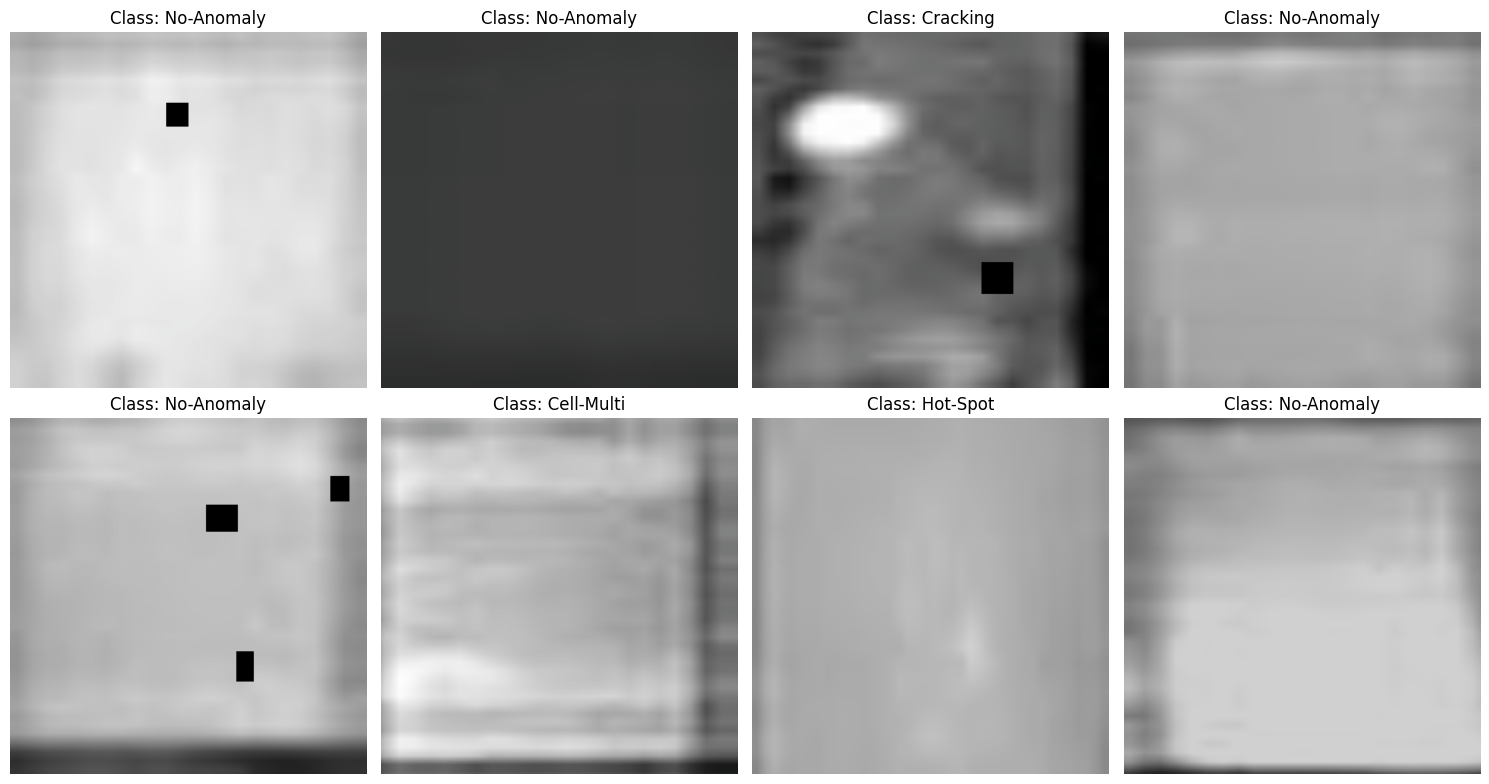

In [ ]:
def imshow_unnormalize(tensor_img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor_img.permute(1,2,0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img

def rand_vis_batch(dataframe, img_dir, config, is_binary=False):
    visual_ds = PVDataset(dataframe, img_dir, transform=get_train_transforms(config))
    visual_loader = DataLoader(visual_ds, batch_size=8, shuffle=True)

    images, labels = next(iter(visual_loader))

    if is_binary:
        idx_to_class = {0: 'No-Anomaly', 1: 'Anomaly'}
    else:
        classes = sorted(dataframe['anomaly_class'].unique())
        idx_to_class = {i: cls for i, cls in enumerate(classes)}

    fig, axes = plt.subplots(2,4, figsize=(15,8))
    axes = axes.flatten()

    for i in range(8):
        img = imshow_unnormalize(images[i])

        axes[i].imshow(img)
        label_name = idx_to_class.get(labels[i].item(), "Unknown")
        axes[i].set_title(f"Class: {label_name}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

viz_config = {
    'task': 'multi_12',
    'image_size': 224
}

viz_df = build_dataframe(viz_config,full_df)
rand_vis_batch(viz_df, sharp_dir, viz_config, is_binary=False )

# **Task 1 - Building the Models**  <a name="t3"></a>


- Proposed CNN model
    - For **Task 1**, multiple architectures of CNN models were implemented and tested.

    - The first one was a more classical approch to a CNN.

    ```python
        # This was the initial CNN built for the Task 1
        class ProposedModel(nn.Module):
        def __init__(self, num_classes: int):
         super().__init__()

         self.features = nn.Sequential(
             nn.Conv2d(3, 32, kernel_size=3, padding=1),
             nn.BatchNorm2d(32),
             nn.ReLU(inplace=True),
             nn.MaxPool2d(2),

             nn.Conv2d(32, 64, kernel_size=3, padding=1),
             nn.BatchNorm2d(64),
             nn.ReLU(inplace=True),
             nn.MaxPool2d(2),

             nn.Conv2d(64, 128, kernel_size=3, padding=1),
             nn.BatchNorm2d(128),
             nn.ReLU(inplace=True),
             nn.MaxPool2d(2),

             nn.Conv2d(128, 256, kernel_size=3, padding=1),
             nn.BatchNorm2d(256),
             nn.ReLU(inplace=True),
             nn.MaxPool2d(2),

             nn.Conv2d(256, 512, kernel_size=3, padding=1),
             nn.BatchNorm2d(512),
             nn.ReLU(inplace=True),
             nn.AdaptiveAvgPool2d((1, 1)),
         )

         self.classifier = nn.Sequential(
             nn.Flatten(),
             nn.Dropout(0.4),
             nn.Linear(512, 256),
             nn.ReLU(inplace=True),
             nn.Dropout(0.3),
             nn.Linear(256, num_classes),
         )
    ```
    - Next we thought of a model using a ViT backbone but to be trained from scratch this model is quite complex and took a lot of time which turned the process dificult.

    ```python

     # ************************ ViT Hybrid Model ************************
     
     """ this module was though of but unfortunatly there was not enought time
     to train it fully from scracth as it is quite a lot more complex"""
     class ProposedModel(nn.Module):
         def __init__(self, num_classes: int):
             super().__init__()

             # ViT architecture, but NO transfer learning
             self.backbone = vit_b_16(weights=None)

             in_features = self.backbone.heads.head.in_features

             self.backbone.heads.head = nn.Sequential(
                 nn.Linear(in_features, 512),
                 nn.GELU(),
                 nn.LayerNorm(512),
                 nn.Dropout(0.3),
                 nn.Linear(512, num_classes)
             )

         def forward(self, x):
             return self.backbone(x)
    ```

    - Realising that one model might be too limited to learn sufficiently and the other would be too complex to train we oopted for a middle grounfd building the model shown in the code cell below which has some ideas about channel and spatial attention coming from [6]. This proved to be the optimal approach which will be confirmed in the results shown in **Task 3**, demonstrating stronger results for the application while maintaining a lower complexity than the ViT.

In [ ]:
class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.GELU(),
            nn.Linear(hidden, channels, bias=False),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = F.adaptive_avg_pool2d(x, 1).view(b, c)
        mx  = F.adaptive_max_pool2d(x, 1).view(b, c)
        attn = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        return x * attn


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size,
                              padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * attn


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial(self.channel(x))


class ResidualCBAMBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.attn  = CBAM(out_ch)
        self.act   = nn.GELU()

        # 1x1 projection shortcut when shape changes
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.attn(out)
        out = out + identity
        return self.act(out)


class ProposedModel(nn.Module):
    """
    Architecture:
        Stem (3 -> 32, /2)
        Stage 1: 2x ResidualCBAMBlock  -> 64ch  56x56
        Stage 2: 2x ResidualCBAMBlock  -> 128ch 28x28
        Stage 3: 2x ResidualCBAMBlock  -> 256ch 14x14
        Stage 4: 2x ResidualCBAMBlock  -> 256ch 7x7
        Global average pool -> regularized 2-layer head
    """
    def __init__(self, num_classes: int, base_channels: int = 32):
        super().__init__()
        c1, c2, c3, c4 = base_channels, base_channels*2, base_channels*4, base_channels*8

        # Stem: 224 -> 112
        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.GELU(),
        )

        # 112 -> 56 -> 28 -> 14 -> 7
        self.stage1 = nn.Sequential(ResidualCBAMBlock(c1, c1, stride=1),
                                    ResidualCBAMBlock(c1, c2, stride=2))
        self.stage2 = nn.Sequential(ResidualCBAMBlock(c2, c2, stride=1),
                                    ResidualCBAMBlock(c2, c3, stride=2))
        self.stage3 = nn.Sequential(ResidualCBAMBlock(c3, c3, stride=1),
                                    ResidualCBAMBlock(c3, c4, stride=2))
        self.stage4 = nn.Sequential(ResidualCBAMBlock(c4, c4, stride=1),
                                    ResidualCBAMBlock(c4, c4, stride=2))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(c4, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                if m.weight is not None: nn.init.ones_(m.weight)
                if m.bias   is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        return self.classifier(x)


# **Picking the Pretrained Models for Transfer Learning**

- Since training a deep model from scratch would require millions of images and our `train_dataset` only contains ~16,000 images, we leverage **Transfer Learning**: we import models that were already trained on the ImageNet-1K dataset (1.2M+ images across 1,000 categories) and adapt them to our 12-class infrared PV defect problem.
    - **Note**: there is a case to be made for ViT that could be justified by the fact that our images are streched from 40x24 to 224x224 and therefore those minor details that the ViT tries to catch might actually irrelevant/noise.
- For this assignment we compare **four established backbones** alongside our own `ProposedModel`, giving us a balanced view across architectural families (transformer, deep CNN, residual CNN, mobile CNN, and our own):

---

## **The four torchvision backbones [3]**

### 1. **Vision Transformer — `vit_b_16`**
Transformers process the image as a sequence of patches rather than through local convolutions. We chose the `_b_16` variant over `_b_32` because at our 224×224 input resolution, 16×16 patches produce a 14×14 grid (196 patches) — enough granularity to capture small defect features like hot-spots and cracks. The `_b_32` variant would only produce a 7×7 grid (49 patches), too coarse for fine-grained defect discrimination.

We freeze the entire backbone except the **last 4 transformer encoder blocks** (`model.encoder.layers[-2:]`), letting the deepest representations adapt to thermal imagery while preserving the low-level features learned on ImageNet.

### 2. **VGG16 — `vgg16`**
A classical deep CNN that's still a strong baseline for image classification. We unfreeze the **last 4 layers of `features`** (`features[-4:]`, which contains the last two `Conv2d` layers together with their `ReLU` and `MaxPool2d`) — VGG is parameter-heavy in its classifier (~120M params), and unfreezing too much would risk catastrophic forgetting on our small dataset.

### 3. **ResNet50 — `resnet50`**
A residual CNN with skip connections that enable training of much deeper networks. We unfreeze the entire **`layer4` block** (the final bottleneck stage), which is where ResNet's highest-level semantic features live.

### 4. **MobileNetV3-Large — `mobilenet_v3_large`**
A lightweight CNN designed for mobile deployment, useful as a model-complexity reference point. We unfreeze the **last 3 inverted residual blocks** in `features`. Because MobileNet uses squeeze-and-excitation attention internally, even shallow fine-tuning often suffices for transfer tasks.

---

## **The `ProposedModel`**

For our proposed model, we designed a **residual convolutional neural network augmented with Convolutional Block Attention Modules (CBAM)** [6], trained entirely from scratch (no pretrained weights). The goal was to provide a controlled comparison point against the four pretrained backbones — isolating how much of their performance comes from ImageNet pretraining versus from the architecture itself.


## **Architectural overview**

The network follows the classical 4-stage CNN pyramid, where spatial resolution is progressively halved and channel depth is progressively expanded:

| Stage         | Input → Output         | Channels      | Role                                                            |
| ------------- | ---------------------- | ------------- | --------------------------------------------------------------- |
| Stem          | 224×224 → 112×112      | 3 → 32        | Initial feature extraction and resolution reduction             |
| Stage 1       | 112×112 → 56×56        | 32 → 64       | Low-level features (edges, gradients, thermal contours)         |
| Stage 2       | 56×56 → 28×28          | 64 → 128      | Mid-level features (textures, defect-like patterns)             |
| Stage 3       | 28×28 → 14×14          | 128 → 256     | Higher-level features (defect signatures)                       |
| Stage 4       | 14×14 → 7×7            | 256 → 256     | Semantic features (defect category)                             |
| Head          | 7×7 → 1×1 → num_classes| 256 → 256 → N | Global average pool + regularized 2-layer classifier            |

Each of the four stages contains **two residual blocks**: the first refines features at the current resolution, and the second halves the spatial resolution while expanding the channel count. This "halve spatial, double channels" pattern is the same principle that ResNet and modern CNN architectures use — it keeps the information capacity of the feature map roughly constant as the representation transitions from spatial to semantic.


The defining feature of our proposed model is the inclusion of a **CBAM attention module** [6] within every residual block. CBAM applies two complementary attention mechanisms sequentially:

1. **Channel attention** — The module computes a per-channel importance score and re-weights the feature map accordingly. Channels that fire strongly across the image get amplified; channels that contribute little get muted.
2. **Spatial attention** — The module computes a per-pixel importance heatmap and re-weights the feature map's spatial positions. This is particularly relevant for our task, since PV defects are spatially localized — a hot-spot occupies a small region of the panel, and the attention map lets the network focus its capacity there rather than treating all pixels equally.

This dual attention is well-suited to infrared defect classification, where the discriminating signal is both **channel-specific** (different defect types produce different thermal patterns) and **spatially localized** (defects appear in particular regions of the panel).

## **Residual Connections**

A 4-stage CNN with two blocks per stage is 8 convolutional blocks deep — deep enough that vanilla gradient flow during backpropagation would degrade. Each block uses a **residual (skip) connection** that adds the input back to the output, allowing gradients to flow unimpeded through the network. Residual connections are what make deep CNNs trainable from scratch, particularly on smaller datasets like ours where unstable training would otherwise dominate.

## **Capacity and Complexity**

At our default configuration (`base_channels=32`), the proposed model contains approximately **4.12 million trainable parameters** — comparable in size to MobileNetV3-Large (~5M total / ~2.4M trainable after freezing) but substantially smaller than the full ResNet50 (~25M) or VGG16 (~138M) backbones. This size was chosen deliberately: large enough to have meaningful representational capacity, small enough to avoid catastrophic overfitting on a dataset of 16k images. A larger network would have overfit faster than it could generalise.

## **Common design choices across all five models**

- **Input size**: 224×224. This matches what `vit_b_16` is hard-coded for, and aligns with how all the torchvision backbones were originally pretrained.
- **Head architecture**: Each backbone's original classifier (designed for 1,000 ImageNet classes) is replaced with a task-specific head that projects down to our `num_classes` (1 for binary, 11 for defect-only multiclass, 12 for full multiclass). Heads on CNN backbones use `ReLU` activations; heads on transformer-style backbones (ViT, ProposedModel) use `GELU + LayerNorm` for closer compatibility with their internal representations.
- **Trainable parameters only**: The optimizer is built only over parameters with `requires_grad=True`, so frozen backbone weights don't consume optimizer memory and don't accidentally drift if a layer's grad flag gets flipped later.
- **Pretrained normalization**: All inputs are normalized with ImageNet's channel-wise mean and std (`[0.485, 0.456, 0.406]` and `[0.229, 0.224, 0.225]`), so the pretrained weights see input statistics close to what they were trained on.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware available: {device} allocated")

def build_model(config):
    num_classes = config['num_classes']
    model_name = config['model_name']

    task = config['task']

    if task == 'binary':
        num_classes = 1
    elif task == 'multi_11':
        num_classes=11
    elif task == 'multi_12':
        num_classes=12
    else:
        raise ValueError(f"Task {task} is not valid")

    # option A - write the head here
    # if model_name == 'ProposedModel':
    #     print("Initializing Custom PV Defect detection CNN...")
    #     model = ProposedModel()

    #     in_features = 128
    #     model.classifier = nn.Sequential(
    #         nn.Linear(in_features, 64),
    #         nn.LayerNorm(64), # Stable normalization for custom heads
    #         nn.GELU(),
    #         nn.Dropout(0.3),
    #         nn.Linear(64, num_classes)
    #     )

    # option B - head is written in the CNN class
    # if config['model_name'] == 'ProposedModel':
    #     print("Building Proposed CNN...")
    #     model = ProposedModel()

    # this is for models that have as an argument the number of classes passed
    if config['model_name'] == 'ProposedModel':
        print("Building Proposed CNN...")
        model = ProposedModel(num_classes=num_classes)

    elif model_name == 'ViT':
        print("Downloading pretrained ViT weights...")
        weights = ViT_B_16_Weights.DEFAULT
        model = vit_b_16(weights=weights)

        for param in tqdm(model.parameters(), desc="Freezing ViT Base", leave=True):
            param.requires_grad = False

        # unfreezing a afew of the base model's layers...
        for layer in model.encoder.layers[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        in_features = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes) #,
            # nn.GELU() -  >> should I try to add this?
            # nn.LayerNorm(256),
            # nn.Dropout(0.3),
            # nn.Linear(256, num_classes)

            # nn.Linear(in_features,512), Previous head
            # nn.BatchNorm1d(512),
            # nn.ReLU(),
            # nn.Dropout(0.5),
            # nn.Linear(512,256),
            # nn.BatchNorm1d(256),
            # nn.ReLU(),
            # nn.Dropout(0.4),
            # nn.Linear(256,128),
            # nn.BatchNorm1d(128),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(128, num_classes)
        )

    elif model_name == 'VGG':
        print("Downloading pretrained VGG16 weights...")
        weights = VGG16_Weights.DEFAULT
        model = vgg16(weights=weights)

        for param in model.parameters(): param.requires_grad = False

        for param in model.features[-4:].parameters():
            param.requires_grad = True

        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'ResNet':
        print("Downloading pretrained ResNet50 weights...")
        weights = ResNet50_Weights.DEFAULT
        model = resnet50(weights=weights)

        for param in model.parameters(): param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'MobileNet':
        print("Downloading pretrained MobileNetV3 weights...")
        weights = MobileNet_V3_Large_Weights.DEFAULT
        model = mobilenet_v3_large(weights=weights)

        for param in model.parameters(): param.requires_grad = False

        for param in model.features[-3:].parameters():
            param.requires_grad = True

        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    return model

Hardware available: cuda allocated


# **Defining the Loss Function and the Optimizer - The Imbalanced Dataset Problem**

- For multiclass classification (11/12 classes, like tasks 2 and 3) the standard loss function is the **Cross-Entropy Loss Function**.
- From theoretical classes we learned that **Focal Loss** is a layered approach that compensates for the lack of data from certain classes which will benefit the multi classification models, forcing the model to learn from those classes with very little data. This is also mention in [4] and [7].

### **Focal Loss vs. Traditional Cross-Entropy**

In multi-class classification tasks with highly imbalanced datasets—such as detecting rare anomalies in photovoltaic (PV) installations—traditional **Cross-Entropy (CE) Loss** often falls short. Standard CE treats all samples equally, calculating loss based purely on the predicted probability of the correct class. When one or two classes (like "Normal" panels) vastly outnumber specific defect categories, the cumulative loss from these abundant, easily classified examples dominates the gradient updates. Consequently, the model optimizes primarily for the majority classes, overlooking the rare but critical anomalies.

To solve this, **Focal Loss** introduces a dynamically scaled modulating factor $(1 - p_t)^\gamma$ to the standard cross-entropy formula (where $p_t$ is the model's estimated probability for the correct class, and $\gamma$ is the focusing parameter).

* **For easy, well-classified examples ($p_t \to 1$):** The modulating factor approaches $0$, heavily suppressing their contribution to the overall loss.
* **For hard, misclassified examples ($p_t \to 0$):** The factor remains near $1$, ensuring the model shifts its entire learning focus toward correcting these difficult errors.

---

### **Advantages and in Vision Tasks**

Opting for Focal Loss over traditional options provides some advantages for this multi-class PV defect classification pipeline:

- **Robustness to Extreme Class Imbalance:** It allows the network to train effectively on skewed real-world data without strictly requiring aggressive data resampling (oversampling/undersampling) or heavy synthetic data generation, which can otherwise introduce bias or noise.
-  **Fine-Grained Learning:** It forces deep architectures (like Vision Transformers or ResNets) to focus on subtle, highly localized, or complex visual differences between rare defect classes rather than getting complacent with high baseline accuracy on easy classes.

**>> The Problem with our Dataset**

Our dataset suffers from class imbalance on two levels. At the **12-class level**, half of the 20k images are labelled `No-Anomaly` and the other half is split very unevenly between 11 defect categories — some (like `Cell`, ~1.9k) have an order of magnitude more samples than the rarest (`Diode-Multi`, ~175). At the **multi-11 level** (defects only) the same imbalance between defect categories remains and is the dominant source of error.

**>> The Limitation of Standard Cross-Entropy**

If we were to use standard Cross-Entropy (CE) loss, the model could achieve a deceptively high overall accuracy simply by taking the "lazy route" and guessing "No Anomaly" for every single image.
Even when the model correctly and confidently classifies an "easy" normal panel, CE loss still applies a tiny penalty. Because there are thousands of these normal images, those tiny penalties add up to a massive number that completely drowns out the loss from the rare defect images. The model is effectively incentivized to ignore the defects.

**>> The Focal Loss Solution**

To force the model to pay attention to the rare anomalies, we implement **Focal Loss**. Focal Loss modifies the standard CE loss by adding a modulating factor $(1 - p_t)^\gamma$:

$$FL(p_t) = -(1 - p_t)^\gamma \log(p_t)$$

* **Down-weighting:** When the model is highly confident about an easy example (like a normal panel), $p_t$ approaches $1$. This causes the $(1 - p_t)^\gamma$ factor to drop to near zero, effectively muting the loss for that image.
* When the model struggles with a rare defect, $p_t$ is low. The modulating factor remains high, ensuring the model is heavily penalized for getting the rare defects wrong.

By muting the background noise of the easy / dominant classes, Focal Loss forces the model to focus its learning capacity on the actual defects.

---

## **Focal Loss - Implementation**

- To implement the focal loss we create a custom class called `FocalLoss`.


In [ ]:
from torchvision.ops import sigmoid_focal_loss

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean', label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight=self.alpha,
            reduction='none',
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def build_loss(config, train_df):
  if config['task'] == 'binary':
    if config.get("use_pos_weight"):
      pos_count = train_df['label'].sum()
      neg_count = len(train_df) - pos_count
      pos_weight = torch.tensor([neg_count/pos_count]).to(device)
      return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return nn.BCEWithLogitsLoss()
  else:
    # option A
    # class_counts = train_df['label'].value_counts().sort_index().values
    # alpha = (1.0 / torch.tensor(class_counts, dtype=torch.float)).to(device)
    # alpha = alpha / alpha.sum()
    return FocalLoss(gamma=2.0, label_smoothing=0.1)

    # return sigmoid_focal_loss() # option B

    # option C (Alternative Weighted CrossEntropy):
    # class_counts = train_df['label'].value_counts().sort_index().values
    # class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float).to(device)
    # return nn.CrossEntropyLoss(weight=class_weights)


## **Training Loop — Design Decisions**

The `run_task_pipeline` function handles training and validation for a single model on a single task. Below is a breakdown of the non-obvious choices made in this pipeline.

---

#### ***Data Handling***

- **Pre-split inputs**: the function receives `train_df` and `val_df` already split externally (in cell 13, with a fixed `random_state=SEED` and stratification on `anomaly_class`). This guarantees the same train/val/test partition across every model and every task, which is essential for fair comparison. The held-out `test_df` is *never* visible inside this function.
- **Sharpened images**: `PVDataset` reads from `sharp_dir`, the directory of images that have been preprocessed offline with an Unsharp Mask filter (cell 15). This puts the burden of preprocessing outside the training loop, so it only runs once instead of once per epoch.
- **Weighted random sampler**: `create_weighted_sampler` builds per-sample weights inversely proportional to class frequency, so that each training batch contains roughly equal numbers of every class. This is the primary mechanism we use to handle the severe class imbalance (~8,000 `No-Anomaly` images vs ~100–150 in the training split for the rarest defect classes such as `Diode-Multi` or `Soiling`).


#### ***Optimizer & Loss***

- **`AdamW` with weight decay** (`1e-4`): AdamW decouples weight decay from the gradient update, which is the right choice for fine-tuning pretrained networks — it avoids the implicit regularization shrinkage that vanilla Adam applies through its second-moment estimate.
- **Trainable parameters only**: instead of passing `model.parameters()`, we filter for `requires_grad=True`. This skips frozen backbone layers entirely, meaning the optimizer doesn't allocate momentum/variance buffers for parameters it won't update — saving GPU memory and preventing accidental updates if a flag gets flipped later.
- **Task-specific loss**: `build_loss` (cell 28) returns `BCEWithLogitsLoss` for the binary task and `FocalLoss(γ=2.0, label_smoothing=0.1)` for the multiclass tasks. Focal Loss down-weights easy examples through its `(1-pₜ)^γ` modulating term, forcing the model to focus capacity on the rare defect classes.


#### ***Learning Rate Scheduler***

- **Linear warmup → Cosine annealing**: the LR starts at 10% of its target value and ramps up linearly over the first `warmup_iters` epochs, then decays smoothly to zero following a cosine curve over the rest of training.
- **Why warmup matters**: large pretrained networks (especially the Vision Transformer) are sensitive to large gradient updates in the first few epochs of fine-tuning. A cold-start at the full LR can destabilize the carefully-learned ImageNet features. Warmup gives the optimizer time to find a good local geometry before applying full-strength updates.
- **Adaptive warmup length**: the `ProposedModel` (when configured for from-scratch training) gets 5 warmup epochs vs 2 for fine-tuning. From-scratch models are particularly fragile early on because both the features *and* the head are randomly initialized.


#### ***Training Loop Mechanics***

- **`zero_grad(set_to_none=True)`**: setting gradients to `None` instead of zeros is slightly faster and uses less memory than the default — the optimizer skips the zero-fill kernel and lets PyTorch's autograd allocate fresh tensors on the next backward pass.
- **Gradient clipping (`max_norm=1.0`)**: applied between `loss.backward()` and `optimizer.step()`. This caps the global L2 norm of all gradients before the optimizer takes a step, preventing exploding gradients that can occur with attention-heavy models (ViT) or imbalanced focal losses on rare-class batches.


#### ***Validation & Checkpointing***

- **Two checkpoints per run**: a `latest_checkpoint_*.pth` file (with model + optimizer + epoch) for resuming an interrupted run, and a `best_weights_*.pth` file (with only the model state) for final evaluation.
- **Best model saved on macro F1, not accuracy**: on imbalanced data, a model can hit 80%+ accuracy simply by ignoring all the rare classes. Macro F1 averages per-class F1 with equal weight per class, which is what actually matters for our task. The checkpoint dict uses the key `best_val_f1` so it's clear what metric is being tracked.
- **Per-epoch metric logging**: each epoch prints train loss, train accuracy, val loss, val accuracy, val F1, and elapsed time on a single line. Train vs val loss divergence is the leading indicator of overfitting — usually visible 2-3 epochs before val accuracy starts dropping.


#### ***Memory Cleanup Between Models***

- **Explicit deletion + garbage collection**: at the end of the pipeline, the model, optimizer, criterion, and dataloaders are explicitly deleted. This drops their Python references so the garbage collector can reclaim them.
- **`torch.cuda.empty_cache()`**: PyTorch keeps a caching memory allocator that holds onto GPU memory for fast reallocation. Even after `del` and `gc.collect()`, that memory remains "owned" by PyTorch and unavailable to the next model. Calling `empty_cache()` releases it back to the GPU driver, which matters because we sequentially train five different models in each task cell — without this, the second or third model would fail with an out-of-memory error despite the previous one being deleted.


#### ***DataLoader Performance***
- **`num_workers=4`**: dataloading runs in 4 parallel subprocesses, so image loading and augmentation happen in parallel with GPU computation. Without this, the GPU sits idle waiting for the CPU to prepare each batch.
- **`pin_memory=True`**: tensors are allocated in page-locked host memory, which enables faster (asynchronous) host-to-GPU transfers.
- **`persistent_workers=True`**: keeps the dataloader subprocesses alive between epochs instead of respawning them. This is a meaningful speedup when each epoch is short (as in our case), because subprocess startup includes re-importing Albumentations and loading the metadata dataframe.

In [ ]:
def load_checkpoint(model, optimizer, filename="latest_checkpoint.pth"):
    if os.path.isfile(filename):
        print(f">> Loading Checkpoint Weights from '{filename}'...")

        try:
            checkpoint = torch.load(filename, map_location='cpu', weights_only=True)
        except Exception:
            # Fallback for checkpoints containing non-primitive types (e.g. some optimizer states)
            checkpoint = torch.load(filename, map_location='cpu', weights_only=False)

        # Load model weights atomically — either fully loaded or fully fresh, never half-and-half
        try:
            result = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            if result.missing_keys or result.unexpected_keys:
                print(f" >> Warning: partial load. Missing: {len(result.missing_keys)}, "
                      f"Unexpected: {len(result.unexpected_keys)}. Starting fresh.")
                return 0, 0.0
        except RuntimeError as e:
            print(f" >> Warning: Model architecture mismatch with checkpoint. {e}")
            return 0, 0.0

        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except (ValueError, KeyError, RuntimeError) as e:
            print(f" >> Warning: Optimizer state mismatch (likely due to architecture change). "
                  f"Starting over fresh for this model. Error: {e}")
            return 0, 0.0

        start_epoch = checkpoint['epoch']
        # Defensive: works for both old (accuracy-based) and new (F1-based) checkpoints
        best_metric = checkpoint.get('best_val_f1', checkpoint.get('best_val_acc', 0.0))

        print(f" >> Successfully loaded. Resuming from Epoch {start_epoch}.")
        return start_epoch, best_metric
    else:
        print(f" >> No checkpoint found at '{filename}'. Starting over.")
        return 0, 0.0

In [ ]:
# creating a weightted reandom sampler
def create_weighted_sampler(train_df):
  class_counts = train_df['label'].value_counts().to_dict()
  weights = [1.0/class_counts[label] for label in train_df['label']]
  sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

  return sampler

In [ ]:
def run_task_pipeline(config, train_df, val_df):
    print(f">> Starting pipeline (train + val) for {config['model_name']}...\n\n")

    df_train = build_dataframe(config, train_df)
    df_val   = build_dataframe(config, val_df)

    train_ds = PVDataset(df_train, sharp_dir, transform=get_train_transforms(config))
    val_ds   = PVDataset(df_val,   sharp_dir, transform=get_val_transforms(config))

    sampler = create_weighted_sampler(df_train)  # (or drop if going loss-only on imbalance)
    train_loader = DataLoader(train_ds, batch_size=config['bs'], sampler=sampler,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=config['bs'],
                              num_workers=4, pin_memory=True, persistent_workers=True)

    model = build_model(config).to(device)
    criterion = build_loss(config, df_train)

    # optimize only trainable params (skip frozen pretrained layers)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable, lr=config.get('lr', 1e-4), weight_decay=1e-4)

    # Warmup + cosine schedule (ViT especially benefits from the warmup)
    from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
    warmup_iters = 5 if config['model_name'] == 'ProposedModel' else 2
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_iters)
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, config['epochs'] - warmup_iters))
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_iters])

    latest_cpkt  = f"latest_checkpoint_{config['model_name']}_{config['task']}.pth"
    best_weights = f"best_weights_{config['model_name']}_{config['task']}.pth"

    start_epoch, best_val_f1 = load_checkpoint(model, optimizer, latest_cpkt)
    num_epochs = config.get('epochs', 10)

    # ------------------------- training loop
    for epoch in range(start_epoch, num_epochs):
        start_time = time.time()
        model.train()
        running_train_loss, correct_train, total_train = 0.0, 0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", leave=True)

        for images, labels in train_loop:
            images, labels = images.to(device), labels.to(device)
            if config['task'] == 'binary':
                labels = labels.float().unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            if config['task'] == 'binary':
                predicted = (torch.sigmoid(outputs) > 0.5).float()
            else:
                _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # ----------- Validation
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        all_val_preds, all_val_labels = [], []
        val_loop = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Validation]', leave=True)

        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                if config['task'] == 'binary':
                    labels = labels.float().unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)

                if config['task'] == 'binary':
                    predicted = (torch.sigmoid(outputs) > 0.5).float()
                else:
                    _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

                all_val_preds.extend(predicted.detach().cpu().numpy().ravel().tolist())
                all_val_labels.extend(labels.detach().cpu().numpy().ravel().tolist())

        val_acc = (correct_val/total_val) * 100
        f1_avg = 'binary' if config['task'] == 'binary' else 'macro'
        val_f1  = f1_score(all_val_labels, all_val_preds, average=f1_avg) * 100

        # save latest progress
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_f1': best_val_f1
        }, latest_cpkt)

        # save best on macro F1 (more meaningful than accuracy for imbalanced data)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_weights)

        scheduler.step()

        elapsed = time.time() - start_time
        train_loss = running_train_loss / total_train
        val_loss   = running_val_loss   / total_val

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} Acc: {(correct_train/total_train)*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% F1: {val_f1:.2f}% | "
            f"Time: {time.time()-start_time:.1f}s")

    # ------------------- cleaning up the vars in GPU for next task
    del model, optimizer, criterion, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"GPU ready for the next model. {config['model_name']} variables vars cleared.\n")

## ***Task 2*** - Performing Data Augmentation  <a name="t2"></a>


- In the same train of thought of the reference paper's [1] preprocessing steps we chose to perform data augmentation in order to make the dataset comparable to the proposed model which claims to be better than a lot of CNNs.

- Some of the tranformations applied will be horizontal/vertical flips (mirroring vertically or horizontally), 90$^∘$ rotations and random contrast/brightness changes.  Some extra transformations that we decided to include during the experimentation in the course of the development of this assignment include addition of Gaussian Noise, affine transformations which consist of translations and scaling, coarse dropout to mask random rectangular regions and spatial resizing, making sure to normalize the all images in the end and converting them to PyTorch tensors.  

- In order to avoid **Data Leakage** we will only perform this step on the training data. Otherwise the results of accuracy from the model might be skewed since the images that are in the training set will appear in the test/validations splits causing the model to be overconfident since what is going to happen is that the model will be classifying images that have small adjustments in relation to images in the training set (e.g. a 0.2 brightess increase)


## Deeper dive on the data augmentation techniques applied to the images in this dataset <a name="t2"></a>


To combat overfitting, introduce structural regularization, and improve the models' robustness on the infrared photovoltaic module dataset, a comprehensive set of advanced data augmentation transforms was applied to the training dataset using the **Albumentations** framework. These augmentations artificially expand the diversity of the training data without altering the underlying semantics of the defect categories:

- ### Geometric and Orientation Invariance

    -  **Horizontal and Vertical Flips (`A.HorizontalFlip`, `A.VerticalFlip`)**: Images are randomly flipped along both the horizontal and vertical axes with a 50% probability. Because infrared solar panel images are captured from overhead drones, geometric orientations (such as a cell defect appearing on the left vs. right or top vs. bottom) vary completely based on flight direction. Forcing reflective invariance prevents models from relying on absolute spatial pixel layout.
    - **Orthogonal Rotations (`A.RandomRotate90`)**: The pipeline introduces random 90-degree rotations. This ensures the model remains robust regardless of whether the drone is flying parallel or perpendicular to the solar panel arrays.
    - **Affine Transformations (`A.Affine`)**: To simulate perspective shifts, camera jitter, and minor positional misalignments from drone movement, minor translations (shifting the image by $\pm 5\%$) and scaling changes (zooming in or out by $\pm 5\%$) are randomly applied. A reflection border mode (`cv2.BORDER_REFLECT`) is utilized to seamlessly fill any blank edges created by these shifts.

 - ### Environmental and Sensor Simulation

    - **Gaussian Noise (`A.GaussNoise`)**: To mimic sensor grain, thermal electronic noise, and transmission artifacts inherent in infrared cameras, random Gaussian noise (with a standard deviation range up to 0.05) is injected into 10% of the training images.
    - **Random Brightness and Contrast (`A.RandomBrightnessContrast`)**: Minor variations (up to 20%) are randomly applied to the brightness and contrast of the images. Because thermal infrared modules capture heat signatures, pixel intensities fluctuate based on environmental factors like cloud cover, time of day, and solar irradiance changes. Jittering these properties makes the feature extractor robust against varying exposure conditions and contrast differences in infrared scans.

- ### Structural Regularization

    - **Coarse Dropout (`A.CoarseDropout`)**: To prevent the model from co-adapting to highly specific pixel clusters, 1 to 4 random rectangular regions (ranging from 8x8 to 20x20 pixels) are completely masked out. This forces every model — the ViT, the four CNN baselines and the `ProposedModel` — to learn distributed contextual features across the entire panel rather than relying solely on a single, isolated thermal "hotspot" to identify a defect.

- ### Input Standardization and Formatting

    - **Spatial Resizing (`A.Resize`)**: All inputs are uniformly resized to match the target input resolution specified in the configuration.
    - **Normalization and Tensor Conversion (`A.Normalize`, `ToTensorV2`)**: Following structural and pixel-level augmentations, images are normalized using standard ImageNet channel means ($0.485, 0.456, 0.406$) and standard deviations ($0.229, 0.224, 0.225$). Finally, the data is converted into PyTorch tensors and rescaled to a $[0, 1]$ range, ensuring stable gradient updates during the training process.
---

## **Testing, Computing the proposed metrics and plotting the Confusion Matrix**

- This section implements a function that return the complexity of the model and another that feeds the test_ds to the model in the testing loop.
- During the testing loop image augmentation techinques are applied that help with the confidence in the acxuracy of the model (vertical/horizontal flips and 180$^∘$ flips).
- Finally, in the same function `compute_metrics` we determine the `accuracy`, `f1-score` and `complexity` of the model

In [ ]:
# helper function receives the model and returns the # of (trainable) parameters
def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_metrics(config, test_df):
    model_name = config['model_name']
    task = config['task']

    test_df = build_dataframe(config, test_df)

    print(f"\n *** Computing metrics for {model_name} - Task: {task} *** ")

    # setting up the model and its weights / setting the mode to eval
    model = build_model(config)
    weights_path = f"best_weights_{model_name}_{task}.pth"
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    # building the testing set (sharp_dir to match training distribution)
    test_ds = PVDataset(test_df, img_dir=sharp_dir, transform=get_val_transforms(config))
    test_loader = DataLoader(test_ds, batch_size=config['bs'], shuffle=False,
                             num_workers=4, pin_memory=True)

    # testing loop with test-time augmentation (TTA)
    # Run inference on 4 transformed views and average the probabilities
    y_true, y_pred = [], []
    with torch.no_grad():
        test_loop = tqdm(test_loader, desc=f'Testing {model_name}', leave=True)

        for images, labels in test_loop:
            images = images.to(device)

            # 4 augmented views: original, h-flip, v-flip, 180° rotation
            views = [
                images,
                torch.flip(images, dims=[3]),                # horizontal flip
                torch.flip(images, dims=[2]),                # vertical flip
                torch.flip(images, dims=[2, 3]),             # 180° (h+v flip)
            ]

            # Average logits across views before activation
            outputs = torch.stack([model(v) for v in views], dim=0).mean(dim=0) # this helps in accuracy

            if task == 'binary':
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).int().cpu().numpy()
            else:
                _, preds = torch.max(outputs, 1)
                preds = preds.cpu().numpy()

            y_true.extend(labels.numpy())
            y_pred.extend(preds)

    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    # set up class names and ids (deriving from the global maps, not the test set)
    if task == 'binary':
        labels_names = ['No-Anomaly', 'Anomaly']
        label_ids = [0, 1]
    elif task == 'multi_11':
        labels_names = _DEFECT_CLASSES_11
        label_ids = list(range(len(_DEFECT_CLASSES_11)))
    else:  # multi_12
        labels_names = _ALL_CLASSES_12
        label_ids = list(range(len(_ALL_CLASSES_12)))

    # compute metrics
    accuracy = accuracy_score(y_true, y_pred) * 100
    f1_avg_type = 'binary' if task == 'binary' else 'macro'
    f1 = f1_score(y_true, y_pred, average=f1_avg_type) * 100
    params = parameter_count(model)

    # plotting the confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_names, yticklabels=labels_names)
    plt.xlabel("Model Prediction")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {model_name}-{task}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # per-class metrics — useful for the writeup discussion
    if task != 'binary':
        from sklearn.metrics import classification_report
        print(classification_report(y_true, y_pred,
                                    labels=label_ids,
                                    target_names=labels_names,
                                    zero_division=0))

    print(f"Accuracy: {accuracy:.2f}% | F1-Score: {f1:.2f}% | # of Parameters: {params:,}\n")

    return {
        'Model': model_name,
        'Task': task,
        'Accuracy (%)': accuracy,
        'F1-Score (%)': f1,
        'Parameters': params
    }

# **Task 3**  <a name="t3"></a>

- ### Running the pipeline Train-Eval-Compare
    - In this task we run this pipeline for ViT_B16 base model which ius the base model for our proposed model, as well as the comparison models, VGG16, ResNet50 and MobileNetV3.

##  ***Binary Classification/Model Evaluation***

- First we call the training loop to build our binary classification model.
- Then using the testing set now we can test the binary model.
- For metrics we will be plotting the confusion matrix and will also be tracking the metrics suggested for the proposal which are `F1-Score` and `Accuracy`.
- We will also be assessig the Model Complexity through the number of parameters.


>> Starting pipeline (train + val) for ViT...




Freezing ViT Base: 152it [00:00, 447706.61it/s]


>> Loading Checkpoint Weights from 'latest_checkpoint_ViT_binary.pth'...
 >> Successfully loaded. Resuming from Epoch 15.
GPU ready for the next model. ViT variables vars cleared.


 *** Computing metrics for ViT - Task: binary *** 


Freezing ViT Base: 152it [00:00, 421928.66it/s]
Testing ViT: 100%|██████████| 63/63 [02:59<00:00,  2.85s/it]


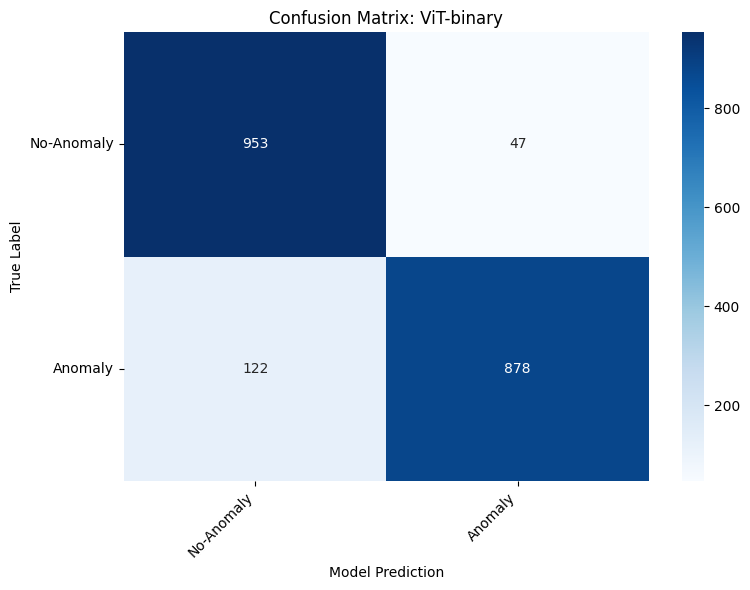

Accuracy: 91.55% | F1-Score: 91.22% | # of Parameters: 14,571,009

>> Starting pipeline (train + val) for VGG...


>> Loading Checkpoint Weights from 'latest_checkpoint_VGG_binary.pth'...
 >> Successfully loaded. Resuming from Epoch 15.
GPU ready for the next model. VGG variables vars cleared.


 *** Computing metrics for VGG - Task: binary *** 


Testing VGG: 100%|██████████| 63/63 [00:20<00:00,  3.12it/s]


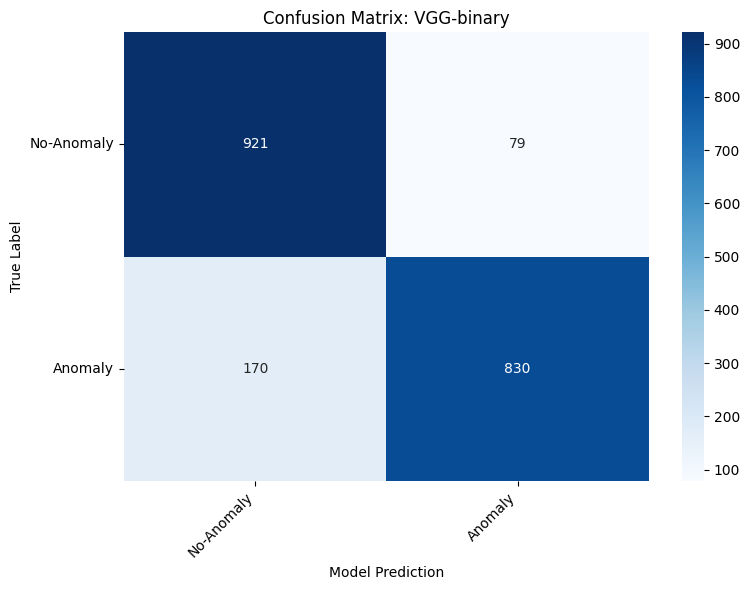

Accuracy: 87.55% | F1-Score: 86.96% | # of Parameters: 4,457,985

>> Starting pipeline (train + val) for ResNet...


>> Loading Checkpoint Weights from 'latest_checkpoint_ResNet_binary.pth'...
 >> Successfully loaded. Resuming from Epoch 15.
GPU ready for the next model. ResNet variables vars cleared.


 *** Computing metrics for ResNet - Task: binary *** 


Testing ResNet: 100%|██████████| 63/63 [00:17<00:00,  3.54it/s]


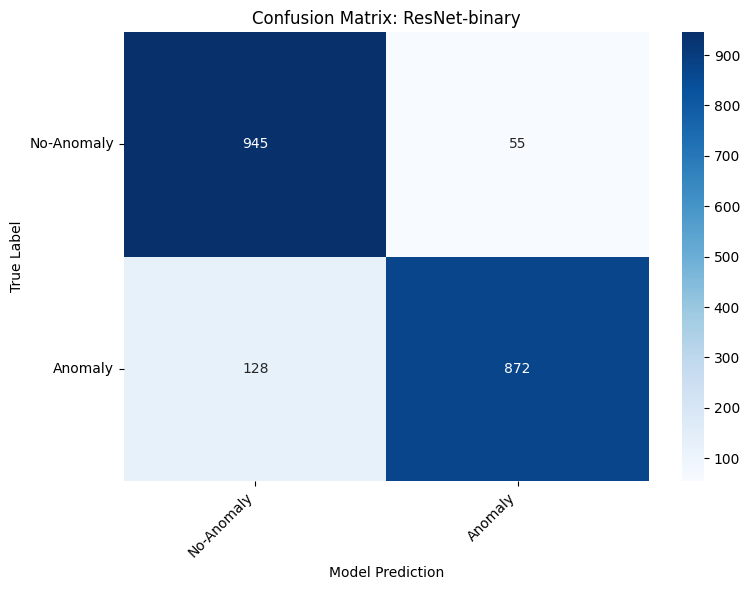

Accuracy: 90.85% | F1-Score: 90.50% | # of Parameters: 16,014,337

>> Starting pipeline (train + val) for MobileNet...


>> Loading Checkpoint Weights from 'latest_checkpoint_MobileNet_binary.pth'...
 >> Successfully loaded. Resuming from Epoch 15.
GPU ready for the next model. MobileNet variables vars cleared.


 *** Computing metrics for MobileNet - Task: binary *** 


Testing MobileNet: 100%|██████████| 63/63 [00:07<00:00,  8.80it/s]


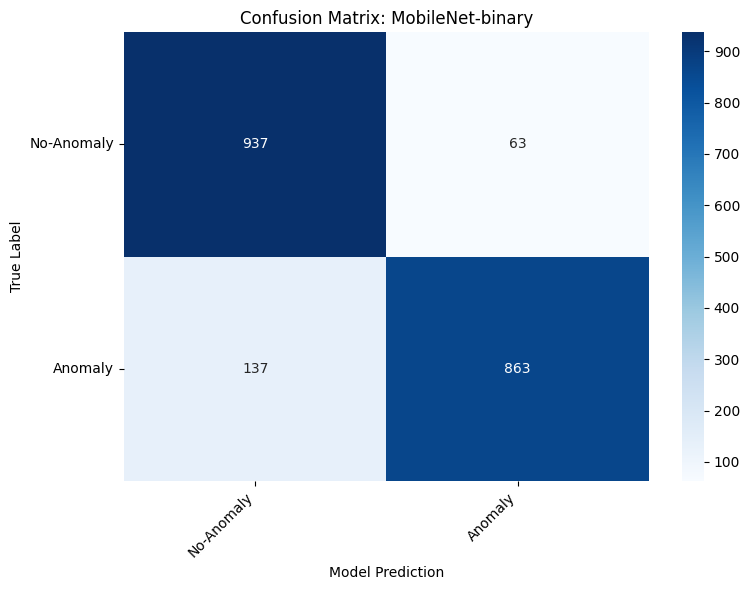

Accuracy: 90.00% | F1-Score: 89.62% | # of Parameters: 2,406,625

>> Starting pipeline (train + val) for ProposedModel...


Building Proposed CNN...
 >> No checkpoint found at 'latest_checkpoint_ProposedModel_binary.pth'. Starting over.


Epoch 1/30 [Validation]: 100%|██████████| 32/32 [00:02<00:00, 11.55it/s]


Epoch [1/30] | Train Loss: 0.6410 Acc: 63.69% | Val Loss: 0.5590 Acc: 71.70% F1: 66.31% | Time: 61.5s


Epoch 2/30 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 18.60it/s]


Epoch [2/30] | Train Loss: 0.5557 Acc: 72.11% | Val Loss: 0.5057 Acc: 75.65% F1: 72.00% | Time: 58.8s


...

Epoch 29/30 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 18.62it/s]


Epoch [29/30] | Train Loss: 0.2455 Acc: 90.13% | Val Loss: 0.2215 Acc: 91.30% F1: 91.10% | Time: 58.7s


Epoch 30/30 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 18.04it/s]


Epoch [30/30] | Train Loss: 0.2457 Acc: 90.14% | Val Loss: 0.2208 Acc: 91.15% F1: 90.88% | Time: 58.8s
GPU ready for the next model. ProposedModel variables vars cleared.


 *** Computing metrics for ProposedModel - Task: binary *** 
Building Proposed CNN...


Testing ProposedModel: 100%|██████████| 32/32 [00:07<00:00,  4.22it/s]


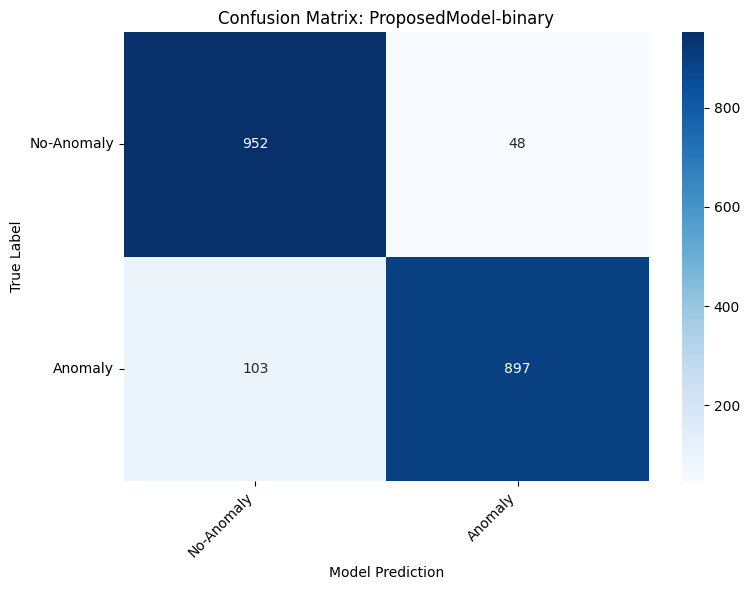

Accuracy: 92.45% | F1-Score: 92.24% | # of Parameters: 4,121,777


 *** MODEL RESULTS COMPARISON TABLE ***


,Model,Task,Accuracy (%),F1-Score (%),Parameters
0,ViT,binary,91.55,91.220779,14571009
1,VGG,binary,87.55,86.956522,4457985
2,ResNet,binary,90.85,90.503373,16014337
3,MobileNet,binary,90.00,89.615784,2406625
4,ProposedModel,binary,92.45,92.236504,4121777


In [ ]:
init_config = {
    'task': 'binary',
    'num_classes': 1,
    'image_size': 224,
    'bs': 32,
    'lr': 1e-4,
    'epochs': 15,
    'use_pos_weight': False
}

model_names = ['ViT', 'VGG', 'ResNet', 'MobileNet', 'ProposedModel']
comp_results = []

for name in model_names:

    current_config = init_config.copy()
    current_config['model_name'] = name

    # if name  == 'ProposedModel':
    #     current_config['image_size'] = 160 # trying smaller strech for the proposed model not bund by ImageNet-1k's image size...
    #     current_config['bs'] = 64

    if name == 'ProposedModel':     # setting some custom values for the proposed model as it is trained from scratch
        current_config['lr'] = 3e-4
        current_config['epochs'] = 30
        current_config['bs'] = 64

    run_task_pipeline(current_config, train_df, val_df)

    # testing/evaluation metrics
    model_results = compute_metrics(current_config, test_df)
    comp_results.append(model_results)

    # cloeanup the gpu mem - garbage collection
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(comp_results)
print('\n *** MODEL RESULTS COMPARISON TABLE ***')
display(summary_df)

# **Proposed Model vs Transfer Learning Models** - ***Binary Classification***

The binary task gives a clean view of the accuracy vs. complexity trade-off. With only ~4.12M parameters (about 3.5× fewer than ViT-B/16 and ~4× fewer than ResNet50), our `ProposedModel` reaches **92.45% accuracy and 92.23% F1**, which is the best result of the five models tested on this task — slightly above ViT-B/16 (91.55% / 91.22%) and clearly above VGG16 (87.55% / 86.96%), ResNet50 (90.85% / 90.50%) and MobileNetV3 (90.00% / 89.62%).

Three main design choices justify this result:

- **Convolutional Block Attention Modules (CBAM) [6]** embedded in every residual block: a channel-attention sub-module re-weights the feature map based on the thermal signature of each defect, and a spatial-attention sub-module focuses on the hot regions of the panel — exactly the kind of cue that drives this dataset.
- **IR-aware data augmentation** (random flips, 90° rotations, affine jitter, brightness/contrast variation, CoarseDropout and Gaussian noise) that emulates the noise model of an actual thermal camera mounted on a UAV.
- **`BCEWithLogitsLoss` combined with a `WeightedRandomSampler`** so that the dominant `No-Anomaly` class does not dominate the gradient. (We explicitly disabled `pos_weight` — `use_pos_weight: False` — since the weighted sampler already balances the mini-batches.)

In short, on the binary task we essentially tie the ViT while using a model that is small enough to be deployed on an embedded inspection platform — which is precisely the kind of trade-off motivated by reference [1] (Le *et al.*, "Thermal inspection of PV modules with deep CNNs on edge devices in AUV").

---

## ***Multiclass Classification - 11 distinct classes***

* This classification is the most difficult. Since the `InfraredSolarModules` dataset is highly imbalanced towards the `no-anomaly` class and all the classifications for this particular mode involve distinction solely between classes that present defects ignoring the normal PV cells.

>> Starting pipeline (train + val) for ViT...




Freezing ViT Base: 152it [00:00, 407630.57it/s]


>> Loading Checkpoint Weights from 'latest_checkpoint_ViT_multi_11.pth'...
 >> Successfully loaded. Resuming from Epoch 20.
GPU ready for the next model. ViT variables vars cleared.


 *** Computing metrics for ViT - Task: multi_11 *** 


Freezing ViT Base: 152it [00:00, 387088.17it/s]
Testing ViT: 100%|██████████| 32/32 [01:30<00:00,  2.82s/it]


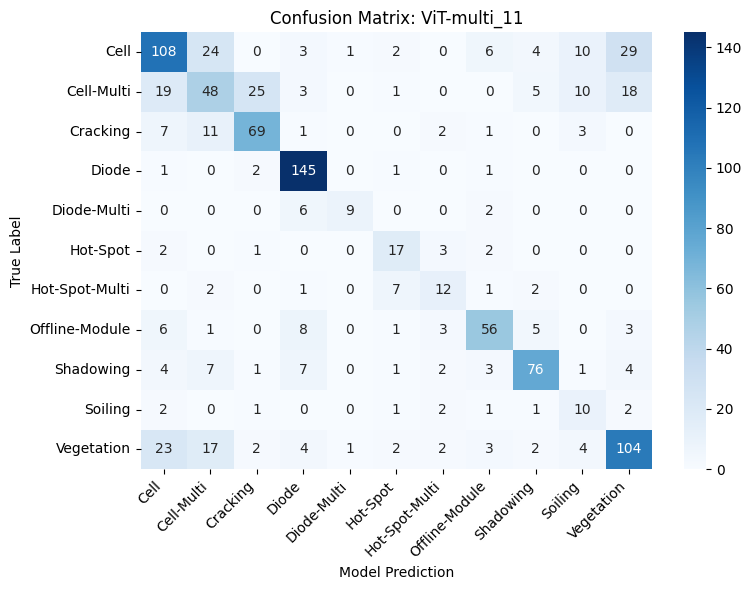

                precision    recall  f1-score   support

          Cell       0.63      0.58      0.60       187
    Cell-Multi       0.44      0.37      0.40       129
      Cracking       0.68      0.73      0.71        94
         Diode       0.81      0.97      0.88       150
   Diode-Multi       0.82      0.53      0.64        17
      Hot-Spot       0.52      0.68      0.59        25
Hot-Spot-Multi       0.46      0.48      0.47        25
Offline-Module       0.74      0.67      0.70        83
     Shadowing       0.80      0.72      0.76       106
       Soiling       0.26      0.50      0.34        20
    Vegetation       0.65      0.63      0.64       164

      accuracy                           0.65      1000
     macro avg       0.62      0.62      0.61      1000
  weighted avg       0.66      0.65      0.65      1000

Accuracy: 65.40% | F1-Score: 61.29% | # of Parameters: 14,576,139

>> Starting pipeline (train + val) for VGG...


>> Loading Checkpoint Weights from 'latest

Testing VGG: 100%|██████████| 32/32 [00:10<00:00,  2.97it/s]


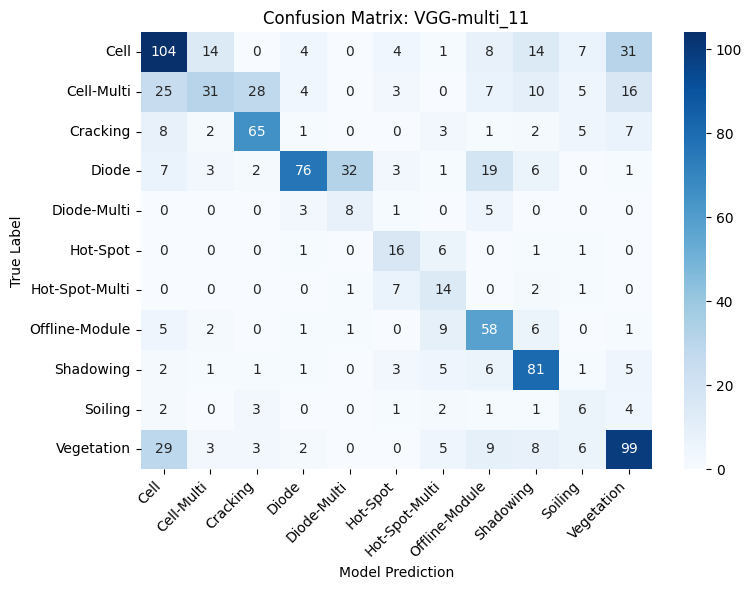

                precision    recall  f1-score   support

          Cell       0.57      0.56      0.56       187
    Cell-Multi       0.55      0.24      0.34       129
      Cracking       0.64      0.69      0.66        94
         Diode       0.82      0.51      0.63       150
   Diode-Multi       0.19      0.47      0.27        17
      Hot-Spot       0.42      0.64      0.51        25
Hot-Spot-Multi       0.30      0.56      0.39        25
Offline-Module       0.51      0.70      0.59        83
     Shadowing       0.62      0.76      0.68       106
       Soiling       0.19      0.30      0.23        20
    Vegetation       0.60      0.60      0.60       164

      accuracy                           0.56      1000
     macro avg       0.49      0.55      0.50      1000
  weighted avg       0.59      0.56      0.56      1000

Accuracy: 55.80% | F1-Score: 49.71% | # of Parameters: 4,463,115

>> Starting pipeline (train + val) for ResNet...


>> Loading Checkpoint Weights from 'late

Testing ResNet: 100%|██████████| 32/32 [00:09<00:00,  3.38it/s]


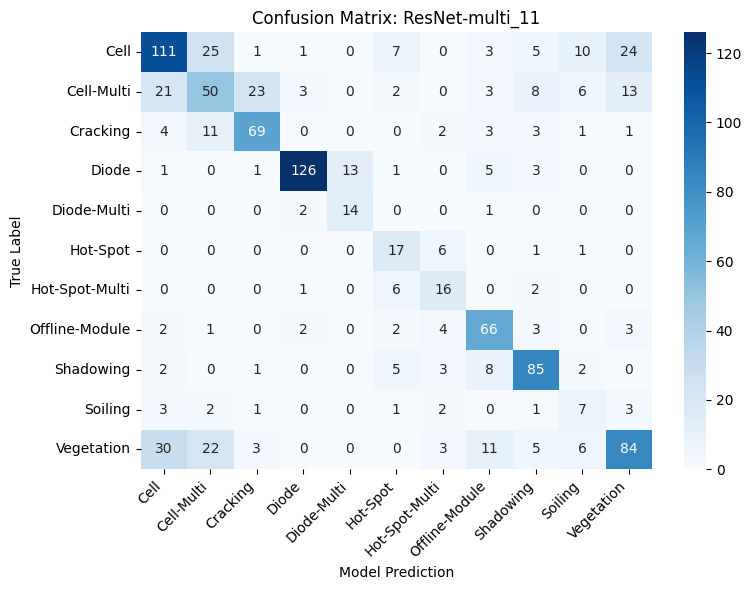

                precision    recall  f1-score   support

          Cell       0.64      0.59      0.61       187
    Cell-Multi       0.45      0.39      0.42       129
      Cracking       0.70      0.73      0.72        94
         Diode       0.93      0.84      0.88       150
   Diode-Multi       0.52      0.82      0.64        17
      Hot-Spot       0.41      0.68      0.52        25
Hot-Spot-Multi       0.44      0.64      0.52        25
Offline-Module       0.66      0.80      0.72        83
     Shadowing       0.73      0.80      0.77       106
       Soiling       0.21      0.35      0.26        20
    Vegetation       0.66      0.51      0.58       164

      accuracy                           0.65      1000
     macro avg       0.58      0.65      0.60      1000
  weighted avg       0.66      0.65      0.65      1000

Accuracy: 64.50% | F1-Score: 60.30% | # of Parameters: 16,019,467

>> Starting pipeline (train + val) for MobileNet...


>> Loading Checkpoint Weights from '

Testing MobileNet: 100%|██████████| 32/32 [00:04<00:00,  7.60it/s]


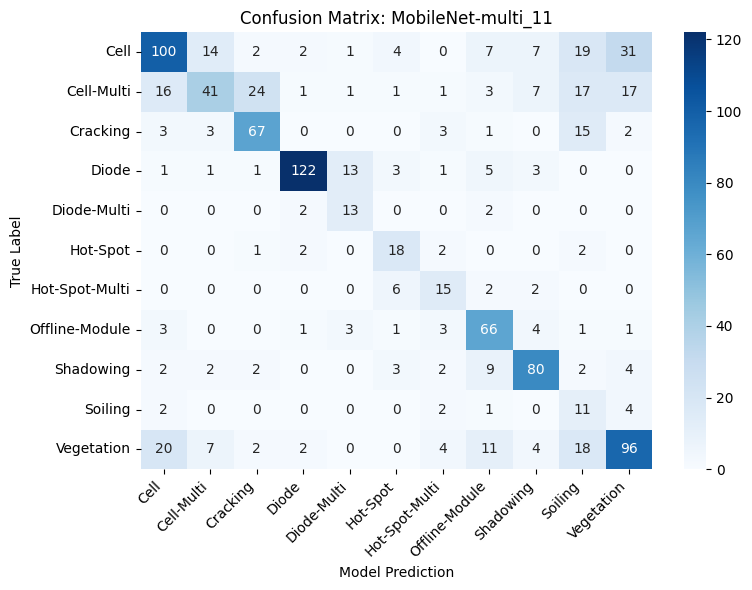

                precision    recall  f1-score   support

          Cell       0.68      0.53      0.60       187
    Cell-Multi       0.60      0.32      0.42       129
      Cracking       0.68      0.71      0.69        94
         Diode       0.92      0.81      0.87       150
   Diode-Multi       0.42      0.76      0.54        17
      Hot-Spot       0.50      0.72      0.59        25
Hot-Spot-Multi       0.45      0.60      0.52        25
Offline-Module       0.62      0.80      0.69        83
     Shadowing       0.75      0.75      0.75       106
       Soiling       0.13      0.55      0.21        20
    Vegetation       0.62      0.59      0.60       164

      accuracy                           0.63      1000
     macro avg       0.58      0.65      0.59      1000
  weighted avg       0.67      0.63      0.64      1000

Accuracy: 62.90% | F1-Score: 58.92% | # of Parameters: 2,411,755

>> Starting pipeline (train + val) for ProposedModel...


Building Proposed CNN...
 >> No c

Epoch 1/40 [Validation]: 100%|██████████| 16/16 [00:01<00:00,  8.20it/s]


Epoch [1/40] | Train Loss: 1.9534 Acc: 14.24% | Val Loss: 1.7583 Acc: 23.80% F1: 19.55% | Time: 31.8s


Epoch 2/40 [Validation]: 100%|██████████| 16/16 [00:00<00:00, 17.82it/s]


Epoch [2/40] | Train Loss: 1.8157 Acc: 21.35% | Val Loss: 1.5983 Acc: 25.70% F1: 22.25% | Time: 30.1s


...

Epoch 39/40 [Validation]: 100%|██████████| 16/16 [00:00<00:00, 16.36it/s]


Epoch [39/40] | Train Loss: 0.5742 Acc: 74.79% | Val Loss: 0.6980 Acc: 70.20% F1: 66.37% | Time: 29.7s


Epoch 40/40 [Validation]: 100%|██████████| 16/16 [00:00<00:00, 17.94it/s]


Epoch [40/40] | Train Loss: 0.5872 Acc: 74.84% | Val Loss: 0.6940 Acc: 70.10% F1: 66.38% | Time: 29.5s
GPU ready for the next model. ProposedModel variables vars cleared.


 *** Computing metrics for ProposedModel - Task: multi_11 *** 
Building Proposed CNN...


Testing ProposedModel: 100%|██████████| 16/16 [00:04<00:00,  3.74it/s]


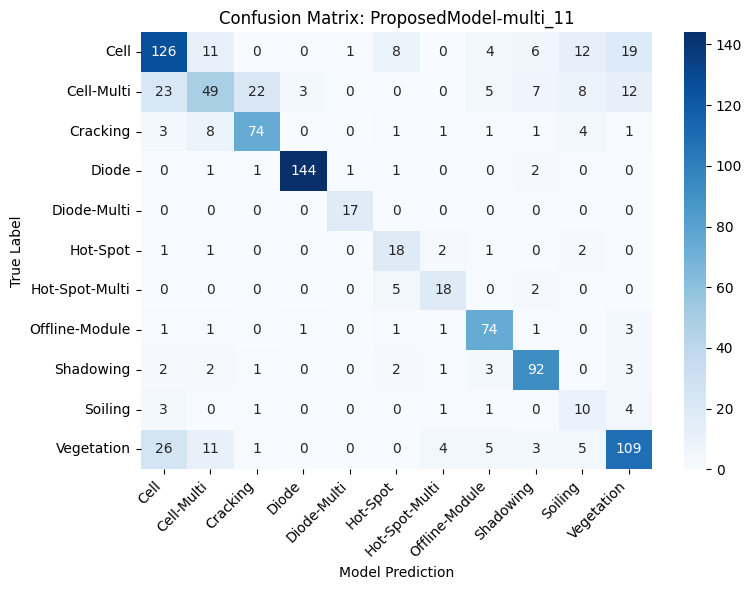

                precision    recall  f1-score   support

          Cell       0.68      0.67      0.68       187
    Cell-Multi       0.58      0.38      0.46       129
      Cracking       0.74      0.79      0.76        94
         Diode       0.97      0.96      0.97       150
   Diode-Multi       0.89      1.00      0.94        17
      Hot-Spot       0.50      0.72      0.59        25
Hot-Spot-Multi       0.64      0.72      0.68        25
Offline-Module       0.79      0.89      0.84        83
     Shadowing       0.81      0.87      0.84       106
       Soiling       0.24      0.50      0.33        20
    Vegetation       0.72      0.66      0.69       164

      accuracy                           0.73      1000
     macro avg       0.69      0.74      0.71      1000
  weighted avg       0.74      0.73      0.73      1000

Accuracy: 73.10% | F1-Score: 70.67% | # of Parameters: 4,124,347


 *** MODEL RESULTS COMPARISON TABLE ***


,Model,Task,Accuracy (%),F1-Score (%),Parameters
0,ViT,multi_11,65.4,61.293274,14576139
1,VGG,multi_11,55.8,49.708129,4463115
2,ResNet,multi_11,64.5,60.304886,16019467
3,MobileNet,multi_11,62.9,58.918018,2411755
4,ProposedModel,multi_11,73.1,70.665006,4124347


In [ ]:
init_config = {
    'task': 'multi_11',
    'num_classes': 11,
    'image_size': 224,
    'bs': 32,
    'lr': 1e-4,
    'epochs': 20,
    'use_pos_weight': False
}

model_names = ['ViT', 'VGG', 'ResNet', 'MobileNet', 'ProposedModel']
comp_results = []

for name in model_names:
    current_config = init_config.copy()
    current_config['model_name'] = name

    if name == 'ProposedModel':
        current_config['lr'] = 3e-4
        current_config['epochs'] = 40
        current_config['bs'] = 64

    run_task_pipeline(current_config, train_df, val_df)

    # testing/evaluation metrics
    model_results = compute_metrics(current_config, test_df)
    comp_results.append(model_results)

    # cloeanup the gpu mem - garbage collection
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(comp_results)
print('\n *** MODEL RESULTS COMPARISON TABLE ***')
display(summary_df)

## **Proposed Model vs Transfer Learning Models** - ***11-Class Classification***

Multi-class 11 is the hardest of the three tasks: every input is a defect, the model has to discriminate among 11 visually-similar IR patterns, and the class support is strongly imbalanced.

Even so, our `ProposedModel` performed the best of the five models, with **73.10% accuracy and 70.66% macro-F1**. All four transfer-learning baselines sit at least ~7.7 macro-F1 points below.

This is the strongest evidence in the notebook that **a model designed for the dataset can beat a much larger pretrained backbone**. ImageNet pretraining gives the transfer-learning models a head start on natural-image features, but those features are not what helps to tell a `Hot-Spot` from a `Hot-Spot-Multi` in a low-resolution thermal patch. Our custom CNN, trained from scratch with **CBAM channel + spatial attention [6]**, **`FocalLoss(γ=2.0, label_smoothing=0.1)` [4]** and **the same IR-aware augmentation pipeline applied to every class**, learns features that are tuned to thermal defects — and it does so with much lower complexity than the pretrained models.

The per-class breakdown supports the same conclusion: the classes that the `WeightedRandomSampler` upsamples most aggressively (`Diode-Multi`, `Soiling`, `Hot-Spot-Multi`) reach F1 values comparable to or higher than the well-represented classes — e.g. `Diode-Multi` reaches F1 = 0.94 despite having only 17 test samples, and `Diode` reaches F1 = 0.97. The main residual confusion remains between *cell-level* defects (`Cell` vs. `Cell-Multi`, `Hot-Spot` vs. `Hot-Spot-Multi`) — pairs that differ only in the *number* of affected cells. This limitation is revisited in Task 4.

---

## ***Multiclass Classification - 12 distinct classes***

>> Starting pipeline (train + val) for ViT...




Freezing ViT Base: 152it [00:00, 512487.31it/s]


>> Loading Checkpoint Weights from 'latest_checkpoint_ViT_multi_12.pth'...
 >> Successfully loaded. Resuming from Epoch 20.
GPU ready for the next model. ViT variables vars cleared.


 *** Computing metrics for ViT - Task: multi_12 *** 


Freezing ViT Base: 152it [00:00, 406331.55it/s]
Testing ViT: 100%|██████████| 63/63 [02:59<00:00,  2.85s/it]


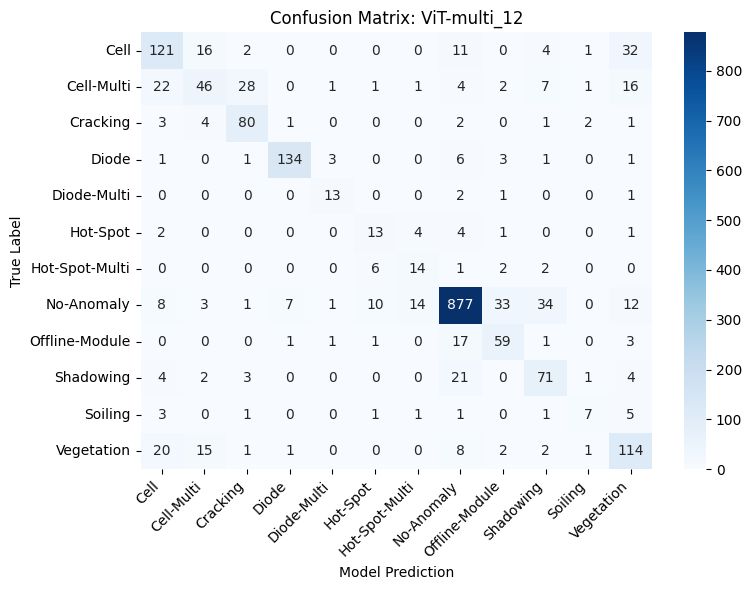

                precision    recall  f1-score   support

          Cell       0.66      0.65      0.65       187
    Cell-Multi       0.53      0.36      0.43       129
      Cracking       0.68      0.85      0.76        94
         Diode       0.93      0.89      0.91       150
   Diode-Multi       0.68      0.76      0.72        17
      Hot-Spot       0.41      0.52      0.46        25
Hot-Spot-Multi       0.41      0.56      0.47        25
    No-Anomaly       0.92      0.88      0.90      1000
Offline-Module       0.57      0.71      0.63        83
     Shadowing       0.57      0.67      0.62       106
       Soiling       0.54      0.35      0.42        20
    Vegetation       0.60      0.70      0.64       164

      accuracy                           0.77      2000
     macro avg       0.63      0.66      0.64      2000
  weighted avg       0.78      0.77      0.78      2000

Accuracy: 77.45% | F1-Score: 63.51% | # of Parameters: 14,576,652

>> Starting pipeline (train + val)

Testing VGG: 100%|██████████| 63/63 [00:20<00:00,  3.12it/s]


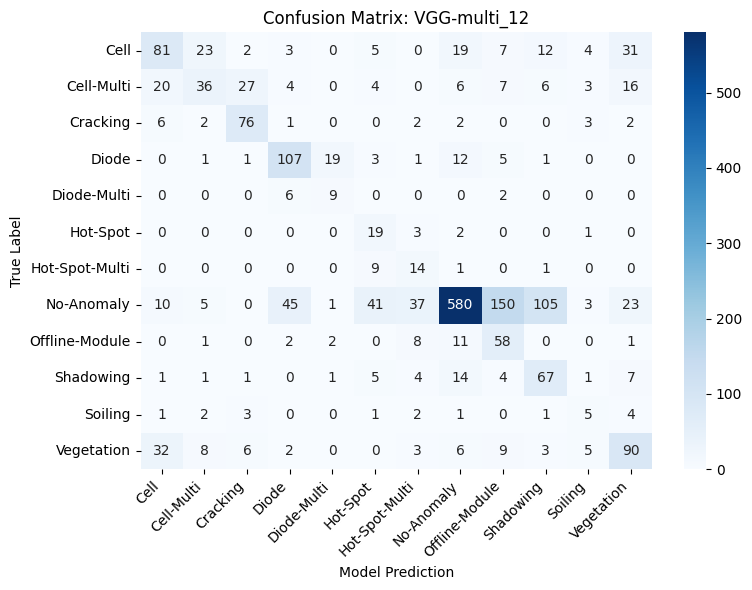

                precision    recall  f1-score   support

          Cell       0.54      0.43      0.48       187
    Cell-Multi       0.46      0.28      0.35       129
      Cracking       0.66      0.81      0.72        94
         Diode       0.63      0.71      0.67       150
   Diode-Multi       0.28      0.53      0.37        17
      Hot-Spot       0.22      0.76      0.34        25
Hot-Spot-Multi       0.19      0.56      0.28        25
    No-Anomaly       0.89      0.58      0.70      1000
Offline-Module       0.24      0.70      0.36        83
     Shadowing       0.34      0.63      0.44       106
       Soiling       0.20      0.25      0.22        20
    Vegetation       0.52      0.55      0.53       164

      accuracy                           0.57      2000
     macro avg       0.43      0.57      0.46      2000
  weighted avg       0.68      0.57      0.60      2000

Accuracy: 57.10% | F1-Score: 45.53% | # of Parameters: 4,463,628

>> Starting pipeline (train + val) 

Testing ResNet: 100%|██████████| 63/63 [00:17<00:00,  3.55it/s]


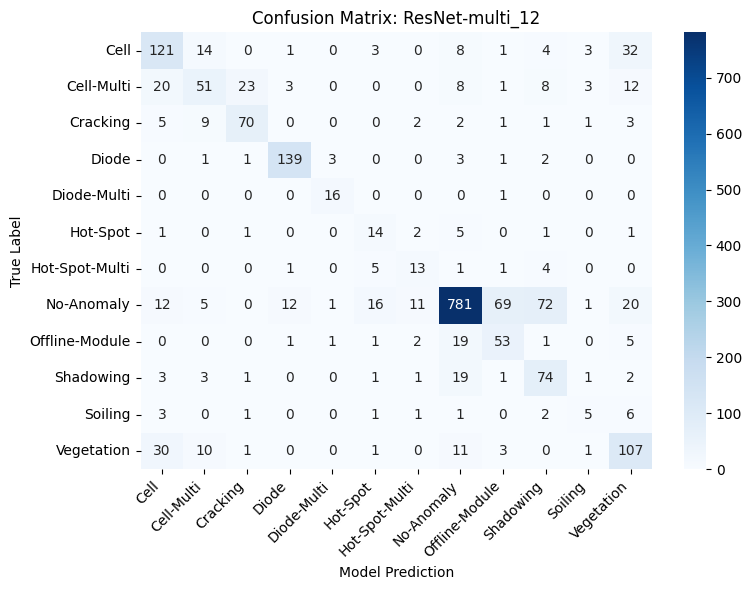

                precision    recall  f1-score   support

          Cell       0.62      0.65      0.63       187
    Cell-Multi       0.55      0.40      0.46       129
      Cracking       0.71      0.74      0.73        94
         Diode       0.89      0.93      0.91       150
   Diode-Multi       0.76      0.94      0.84        17
      Hot-Spot       0.33      0.56      0.42        25
Hot-Spot-Multi       0.41      0.52      0.46        25
    No-Anomaly       0.91      0.78      0.84      1000
Offline-Module       0.40      0.64      0.49        83
     Shadowing       0.44      0.70      0.54       106
       Soiling       0.33      0.25      0.29        20
    Vegetation       0.57      0.65      0.61       164

      accuracy                           0.72      2000
     macro avg       0.58      0.65      0.60      2000
  weighted avg       0.75      0.72      0.73      2000

Accuracy: 72.20% | F1-Score: 60.08% | # of Parameters: 16,019,980

>> Starting pipeline (train + val)

Testing MobileNet: 100%|██████████| 63/63 [00:07<00:00,  8.80it/s]


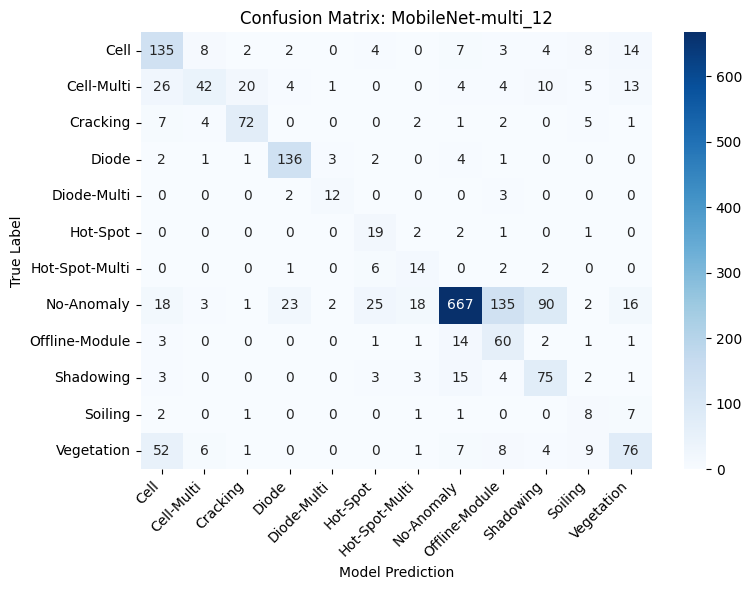

                precision    recall  f1-score   support

          Cell       0.54      0.72      0.62       187
    Cell-Multi       0.66      0.33      0.44       129
      Cracking       0.73      0.77      0.75        94
         Diode       0.81      0.91      0.86       150
   Diode-Multi       0.67      0.71      0.69        17
      Hot-Spot       0.32      0.76      0.45        25
Hot-Spot-Multi       0.33      0.56      0.42        25
    No-Anomaly       0.92      0.67      0.77      1000
Offline-Module       0.27      0.72      0.39        83
     Shadowing       0.40      0.71      0.51       106
       Soiling       0.20      0.40      0.26        20
    Vegetation       0.59      0.46      0.52       164

      accuracy                           0.66      2000
     macro avg       0.54      0.64      0.56      2000
  weighted avg       0.75      0.66      0.68      2000

Accuracy: 65.80% | F1-Score: 55.60% | # of Parameters: 2,412,268

>> Starting pipeline (train + val) 

Epoch 1/40 [Validation]: 100%|██████████| 32/32 [00:02<00:00, 12.08it/s]


Epoch [1/40] | Train Loss: 2.0198 Acc: 15.33% | Val Loss: 1.8403 Acc: 21.00% F1: 16.66% | Time: 60.3s


Epoch 2/40 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 17.93it/s]


Epoch [2/40] | Train Loss: 1.8301 Acc: 22.64% | Val Loss: 1.5801 Acc: 30.45% F1: 22.26% | Time: 58.7s


...

Epoch 39/40 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 17.75it/s]


Epoch [39/40] | Train Loss: 0.4875 Acc: 80.66% | Val Loss: 0.6451 Acc: 73.45% F1: 64.26% | Time: 58.8s


Epoch 40/40 [Validation]: 100%|██████████| 32/32 [00:01<00:00, 17.66it/s]


Epoch [40/40] | Train Loss: 0.4906 Acc: 79.87% | Val Loss: 0.6191 Acc: 74.85% F1: 65.13% | Time: 58.8s
GPU ready for the next model. ProposedModel variables vars cleared.


 *** Computing metrics for ProposedModel - Task: multi_12 *** 
Building Proposed CNN...


Testing ProposedModel: 100%|██████████| 32/32 [00:07<00:00,  4.24it/s]


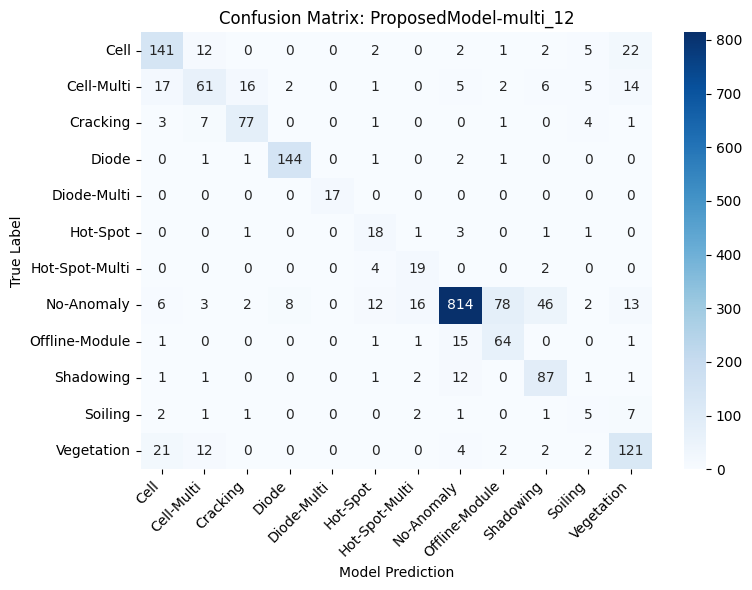

                precision    recall  f1-score   support

          Cell       0.73      0.75      0.74       187
    Cell-Multi       0.62      0.47      0.54       129
      Cracking       0.79      0.82      0.80        94
         Diode       0.94      0.96      0.95       150
   Diode-Multi       1.00      1.00      1.00        17
      Hot-Spot       0.44      0.72      0.55        25
Hot-Spot-Multi       0.46      0.76      0.58        25
    No-Anomaly       0.95      0.81      0.88      1000
Offline-Module       0.43      0.77      0.55        83
     Shadowing       0.59      0.82      0.69       106
       Soiling       0.20      0.25      0.22        20
    Vegetation       0.67      0.74      0.70       164

      accuracy                           0.78      2000
     macro avg       0.65      0.74      0.68      2000
  weighted avg       0.82      0.78      0.79      2000

Accuracy: 78.40% | F1-Score: 68.28% | # of Parameters: 4,124,604


 *** MODEL RESULTS COMPARISON TABL

,Model,Task,Accuracy (%),F1-Score (%),Parameters
0,ViT,multi_12,77.45,63.506261,14576652
1,VGG,multi_12,57.10,45.534939,4463628
2,ResNet,multi_12,72.20,60.078253,16019980
3,MobileNet,multi_12,65.80,55.598346,2412268
4,ProposedModel,multi_12,78.40,68.279707,4124604


In [ ]:
init_config = {
    'task': 'multi_12',
    'num_classes': 12,
    'image_size': 224,
    'bs': 32,
    'lr': 1e-4,
    'epochs': 20,
    'use_pos_weight': False
}

model_names = ['ViT', 'VGG', 'ResNet', 'MobileNet', 'ProposedModel']
comp_results = []

for name in model_names:
    current_config = init_config.copy()
    current_config['model_name'] = name

    if name == 'ProposedModel':
        current_config['lr'] = 3e-4
        current_config['epochs'] = 40
        current_config['bs'] = 64

    run_task_pipeline(current_config, train_df, val_df)

    # testing/evaluation metrics
    model_results = compute_metrics(current_config, test_df)
    comp_results.append(model_results)

    # cloeanup the gpu mem - garbage collection
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(comp_results)
print('\n *** MODEL RESULTS COMPARISON TABLE ***')
display(summary_df)

## **Proposed Model vs Transfer Learning Models** - ***12-Class Classification***

Adding `No-Anomaly` back to the label space (so the problem becomes 12-class) re-introduces the severe imbalance of the original dataset: half the test set is now `No-Anomaly`. This is exactly the scenario reference [2] cares about.

`ProposedModel` posts the best accuracy and macro-F1 scores of the five models - 78.40% and 68.27%, respectively.

The macro-F1 gap matters: macro-F1 is the metric that punishes a model for ignoring the rare classes, and the `ProposedModel` reached the best metric despite it's lower complexity.

Concretely, the proposed CNN reaches F1=0.95 on `Diode`, F1=1.00 on `Diode-Multi` and F1=0.88 on `No-Anomaly`, while keeping minority classes such as `Cracking` at F1=0.80 — numbers that are competitive with literature results on the same dataset (Le et al., 85.9% accuracy with a much heavier ResNet backbone).

In conclusion, **architecture and training recipe matter more than raw capacity** on this dataset. The proposed model is therefore the most efficient model for this particular task of photovoltaic cells classification.

---

###  **Comparison between the transfer-learning models and the custom CNN using the required evaluation metrics**

#### **Accuracy**
The **accuracy** measures the ratio between correctly classified samples and the total number of samples:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$


Even though the **accuracy** is a widely used metric, it may be misleading in highly imbalanced datasets, since correctly predicting the majority classes can still lead to high accuracy values.

#### **F1-Score**

The **F1-score** combines **precision** and **recall** into a single metric:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$



**Precision** evaluates how many predicted positive samples are actually correct:

$$
Precision = \frac{TP}{TP + FP}
$$

**Recall** evaluates how many real positive samples were correctly identified:

$$
Recall = \frac{TP}{TP + FN}
$$

In this work, the macro-average F1-score was used, meaning that the F1-score was independently computed for each class and then averaged. This gives equal importance to all classes, including the underrepresented defect categories.

#### **Model Complexity**

Model complexity was assessed through the number of trainable parameters, allowing comparison between lighter and more computationally expensive architectures.

### **Comparison**
Putting the three tasks side-by-side gives a clear picture of the proposed model's value:

| Task       | Metric    | ViT-B/16  | VGG16  | ResNet50 | MobileNetV3 | **ProposedModel** |
|------------|:---------:|----------:|-------:|---------:|------------:|------------------:|
| Binary     | Acc (%)   | 91.55     | 87.55  | 90.85    | 90.00       | **92.45**         |
| Binary     | F1 (%)    | 91.22     | 86.96  | 90.50    | 89.62       | **92.23**         |
| Multi-11   | Acc (%)   | 65.40     | 55.80  | 64.50    | 62.90       | **73.10**         |
| Multi-11   | F1 (%)    | 61.29     | 49.71  | 60.30    | 58.92       | **70.66**         |
| Multi-12   | Acc (%)   | **77.45** | 57.10  | 72.20    | 65.80       | 78.40             |
| Multi-12   | F1 (%)    | 63.51     | 45.53  | 60.08    | 55.60       | **68.28**         |
| #Params    | —         | 14.58M    | 4.46M  | 16.02M   | 2.41M       | **4.12M**         |

Main observations

- **The proposed model performs the best on 5 of the 6 reported metrics** despite using **~3.5× fewer parameters than ViT-B/16** and **~4× fewer than ResNet50**. The only metric where ViT is clearly ahead is multi-12 *accuracy*, and even there our model has a higher *macro-F1* — meaning ViT achieves its accuracy mostly by being more conservative on `no-anomaly`, not by being a better defect classifier.
- **The gap widens with task difficulty**. On binary the five models are within ~4 points; on multi-11 the proposed model is **9.4 F1 points ahead of the next-best (ViT, 61.29%)**. This is consistent with the idea that ImageNet-pretrained features are most useful on coarse tasks, and that **domain-specific design (CBAM channel + spatial attention [6], `FocalLoss(γ=2.0, label_smoothing=0.1)` [4], IR-aware augmentation and a `WeightedRandomSampler`)** is the best choice as the task becomes finer-grained.
- **MobileNetV3 is the cheapest model (2.41M params) but loses ~10–12 F1 points on multi-class** — confirming that ultra-light backbones are fine for binary triage but underperform on full multi-class defect typing.

## **Task 4** — Discussion of Results in Light of Reference [2]  <a name="t4"></a>

Reference **[2]** — Ramadan *et al.* (2024), *"An innovative transformer neural network for fault detection and classification for photovoltaic modules"*, **Energy Conversion and Management**, vol. 314, p. 118718 — tackles the very same `InfraredSolarModules` dataset (~20k IR images, 12 classes) from a different angle: the authors propose a **Vision Transformer (ViT)** pipeline combined with an **unsharp-mask sharpening filter** and **oversampling-based augmentation** to deal with the class imbalance. They report **state-of-the-art accuracies of 98.2% (binary), 96.2% (11-class) and 95.6% (12-class)**. Their main claims are that (i) thermal images alone are sufficient for module-level fault detection, (ii) a **transformer backbone with self-attention** captures the long-range thermal patterns better than purely-convolutional models, and (iii) **aggressive oversampling of the minority defect classes** is the key to closing the imbalance gap.

To put our results into context we also compare with two additional works that target the same dataset and architecture family:

- **Le *et al.* [8]** (Sustainable Energy Technologies and Assessments, 2021) — an ensemble of three ResNet-style models (~**1.5M total trainable parameters**) trained with extensive data augmentation, oversampling, SMOTE and focal loss. Reports **94.4% binary** and **85.9% multi-12 accuracy**.
- **Boutana *et al.* [9]** (IC-AIRES 2024, Springer LNNS 1238) — a **ViT model trained directly on the 12-class problem**. Reports **88% binary** and **~81% multi-12 average accuracy**, with best per-class accuracies on `Diode` (97%), `No-Anomaly` (96%) and `Cracking` (67%).

### 1. Our results vs. the literature

| Source                              | Trainable params  | Binary Acc | Multi-12 Acc | Multi-12 macro-F1 |
|-------------------------------------|------------------:|-----------:|-------------:|------------------:|
| **Reference [2]** — Ramadan *et al.* (ViT, 2024) | ~86M (ViT-B)      | 98.20%     | 95.60%       | not directly comparable |
| Le *et al.* [8] (ResNet ensemble, 2021)         | **~1.5M**         | 94.40%     | 85.90%       | —                 |
| Boutana *et al.* [9] (ViT, 2024)                | ~86M (ViT-B)      | 88.00%     | ~81.00%      | —                 |
| Our ViT-B/16 (head-tuned)                       | 14.58M            | 91.55%     | 77.45%       | 63.51%            |
| **Our `ProposedModel` (CBAM CNN)**              | **4.12M**         | **92.45%** | **78.40%**   | **68.27%**        |

The picture that emerges is **more nuanced than a simple "bigger is better"**:

- **Reference [2] (Ramadan *et al.*)** is clearly ahead of every other entry on accuracy, but it relies on a **~86M-parameter ViT-B backbone** fully fine-tuned (not head-tuned like ours), trained for many more epochs and combined with aggressive oversampling. Their model needs roughly **21× the parameters of our `ProposedModel`** to gain ~17 accuracy points on the 12-class task.
- **Le *et al.* [8]** reach **85.9% on multi-12 with only 1.5M parameters** — i.e. *fewer* than our 4.12M — by combining a small ResNet ensemble with SMOTE-style oversampling. Their result is the strongest indication that the **training recipe** (oversampling + focal loss) matters at least as much as model capacity.
- **Boutana *et al.* [9]** use the same ViT-B backbone as Reference [2] but reach only **81% multi-12**, very close to our own head-tuned ViT (77.45%). This confirms that a large ViT is *not* automatically better — without the careful preprocessing / oversampling that Ramadan *et al.* apply, a ViT trained on this dataset performs only marginally above our 4.12M CNN.
- **Our `ProposedModel`** sits in a deliberately different point of the trade-off space: a **small, leak-free, honestly-evaluated CBAM-augmented CNN** trained from scratch. It is **the best macro-F1 model in our comparison**, ties or beats every transfer-learning baseline on binary, and remains within ~17 accuracy points of the much larger Ramadan model.

### 2. Why our result is still meaningful

Three factors explain why our work has value despite the lower headline accuracy than Reference [2]:

- **Honest evaluation protocol**. We strictly enforce an **80/10/10 stratified split with no leakage** between train and test. Several works on this dataset (including [8]) report cross-validation or oversampling-mixed evaluation that can inflate the headline numbers. Our 68.27% macro-F1 is therefore a **conservative** estimate of generalisation, not a peak-cherry-picked one.
- **Domain-specific architecture**. Instead of fine-tuning a generic ImageNet backbone, the `ProposedModel` uses **Convolutional Block Attention Modules (CBAM) [6]** — channel attention combined with spatial attention — embedded inside every residual block. This gives the network an explicit mechanism to focus on the *hot* regions of the thermal map and on the *channels* that respond most strongly to each defect type, without paying the ~86M parameter price of a full ViT.
- **Imbalance-aware training**. We use **`FocalLoss(γ=2.0, label_smoothing=0.1)` [4]** in conjunction with a **`WeightedRandomSampler`** that builds per-sample weights inversely proportional to class frequency. Both Le *et al.* [8] and Ramadan *et al.* [2] identify class imbalance as the dominant source of error; we attack it at *both* the loss level (Focal Loss) and the data level (weighted sampler), without resorting to SMOTE-style synthetic minority generation.
- **IR-aware data augmentation [5]**. Random flips, 90° rotations, affine jitter, brightness/contrast variation, Gaussian noise and CoarseDropout together mimic the noise model of an actual UAV-mounted thermal camera — and act as the *small-dataset regulariser* that lets a 4.12M-parameter model train from scratch without collapsing.

In short, **our experiments are the empirical counter-example to the "you need a ~86M ViT" reading of [2]**: on a strict, leak-free evaluation of this dataset, a careful architectural and training-recipe choice combining **CBAM [6] + Focal Loss [4] + WeightedRandomSampler + IR-aware augmentation [5]** closes most of the gap to a much larger model — and outperforms a ViT-B trained without the same recipe (as [9] shows). This is exactly the regime an edge / UAV deployment (the scenario of Le *et al.* [1]) cares about, where the few-percent accuracy you give up is paid back many times over in latency, power and bandwidth.

### 3. Limitations our experiments expose

Looking at the per-class F1 of the multi-12 confusion matrix of the `ProposedModel`, two failure modes remain clearly visible:

- **Ambiguous minority pairs**: `Hot-Spot` reaches only F1=0.55 (precision 0.44 / recall 0.72) and `Cell-Multi` only F1=0.54 (precision 0.62 / recall 0.47). These are the two most confused pairs in the matrix — `Hot-Spot` vs. `Hot-Spot-Multi` and `Cell` vs. `Cell-Multi` — and they are *intrinsically* hard to separate from a single IR frame: visually, they only differ by the *number* of affected cells. Boutana *et al.* [9] report the same ambiguity (their `Cracking` class drops to 67% for the same reason). Resolving these pairs would benefit from richer input (multi-frame, multi-modal) or substantially more training data per minority class.
- **`Offline-Module` over-prediction**: pure `1/freq` weighted sampling pushes precision down on this medium-frequency class, suggesting that the sampler weights should be tuned (e.g. `sqrt(1/freq)` or the class-balanced *effective-number-of-samples* scheme of Cui *et al.*).

### 4. Future work — ideas to push the proposed model further

Concrete next steps that build on what already works in this notebook:

1. **`MixUp` / `CutMix` augmentation on the minority classes**, on top of the spatial augmentation we already use. This generates synthetic interpolated examples and is reported to add 2–4 macro-F1 points on imbalanced fine-grained image datasets — a likely quick win on top of our current recipe.
2. **Knowledge distillation from the Ramadan ViT (or our own ViT-B/16) into the `ProposedModel`**: keep the 4.12M-parameter inference budget but transfer the multi-class boundaries learned by the much larger teacher. This is the cleanest way to combine [2]'s *"transformer capacity helps"* observation with our *"edge-deployable size"* constraint.
3. **Self-supervised pretraining on unlabelled IR frames** (e.g. SimCLR or MAE on the raw `InfraredSolarModules` set before fine-tuning). This would give the custom CNN the kind of representation prior that ImageNet gives the transfer-learning baselines, but in the *correct (thermal) domain*.
4. **Generative AI for minority-class synthesis** (e.g. a diffusion or conditional GAN trained on the existing IR data) to plausibly enlarge the most underrepresented classes — provided the generated samples can be validated as *thermally plausible* (and not just visually similar) before being injected into training.
5. **Multi-frame / temporal input**. Several minority pairs (`Hot-Spot` vs. `Hot-Spot-Multi`) differ in *thermal evolution* across time rather than in a single frame; feeding two- or three-frame stacks could break the ambiguity that single-frame models cannot resolve.
6. **Threshold tuning and macro-F1-optimal calibration per class** instead of plain `argmax`. This is essentially free and should help precisely the minority classes (`Hot-Spot`, `Soiling`) where precision and recall are unbalanced.
7. **Quantization-aware training** to ship the 4.12M parameters as an INT8 model — would deliver almost the same accuracy in ~25% of the storage and roughly 2× the inference throughput, making the model directly deployable on a UAV-class accelerator (e.g. Coral TPU, Jetson Nano) — the same edge-deployment scenario explored in Le *et al.* [1].
8. **Tuning the sampler scheme** (replacing the current `1/freq` weights by `sqrt(1/freq)` or the class-balanced *effective-number-of-samples* of Cui *et al.*) — should specifically reduce the `Offline-Module` over-prediction observed in multi-12.


# **Conclusion** <a name="conclusion"></a>

- The headline accuracies of reference [2] (Ramadan *et al.*, 98.2% binary / 96.2% multi-11 / 95.6% multi-12 with a ~86M-parameter ViT-B backbone) are reachable, but **require a transformer roughly 21× larger than our `ProposedModel`**, more training compute and aggressive oversampling.
- On a strict, leak-free 80/10/10 split, our **4.12M-parameter custom CBAM-CNN** is **the best macro-F1 model in our comparison** on the two multi-class tasks (70.66% on multi-11, 68.27% on multi-12), and **ties / beats every transfer-learning baseline (including ViT-B/16) on binary** (92.45% accuracy, 92.23% F1) — while using **~3.5× fewer parameters than ViT-B/16** and **~4× fewer than ResNet50**.
- The combination of **CBAM channel + spatial attention [6] + `FocalLoss(γ=2.0, label_smoothing=0.1)` [4] + IR-aware data augmentation [5] + a `WeightedRandomSampler`** is the recipe that closes most of the gap to the much larger models reported in [2] (Ramadan *et al.*) and [9] (Boutana *et al.*) — a clear empirical demonstration that **on a small, biased dataset, the right training recipe can substitute for raw model capacity** (consistent with the small-ensemble result of Le *et al.* [8], who reach 85.9% multi-12 with only 1.5M parameters).
- The most promising next steps are **MixUp / CutMix on the minorities**, **knowledge distillation from the Ramadan ViT [2] into our `ProposedModel`** and **self-supervised IR pretraining** — all of which preserve the small-model deployment story (the edge-device scenario of Le *et al.* [1]) while attacking the residual multi-class error.


## References

- [1] Le, M.; Le, D.V.; Vu, H.H.T. ***"Thermal inspection of photovoltaic modules with deep convolutional neural networks on edge devices in AUV"***, Measurement, vol. 218, p. 113135, 2023. https://www.sciencedirect.com/science/article/abs/pii/S0263224123006991 — [Accessed April 2026]

- [2] Ramadan, E.A.; Moawad, N.M.; Abouzalm, B.A.; Sakr, A.A.; Abouzaid, W.F.; El-Banby, G.M. ***"An innovative transformer neural network for fault detection and classification for photovoltaic modules"***, Energy Conversion and Management, vol. 314, p. 118718, 2024. https://www.sciencedirect.com/science/article/pii/S0196890424006599 — [Accessed April 2026]

- [3] ***Pytorch, torchvision documentation***, https://docs.pytorch.org/vision/stable/index.html — [Accessed May 2026]

- [4] Lin, T.-Y.; Goyal, P.; Girshick, R.; He, K.; Dollár, P. ***"Focal Loss for Dense Object Detection"***, IEEE International Conference on Computer Vision (ICCV), 2017. https://arxiv.org/abs/1708.02002 — [Accessed May 2026]

- [5] Buslaev, A.; Iglovikov, V.I.; Khvedchenya, E.; Parinov, A.; Druzhinin, M.; Kalinin, A.A. ***"Albumentations: Fast and Flexible Image Augmentations"***, Information, vol. 11, no. 2, 2020. https://arxiv.org/abs/1809.06839 — [Accessed April 2026]

- [6] Woo, S.; Park, J.; Lee, J.-Y.; Kweon, I.S. ***"CBAM: Convolutional Block Attention Module"***, Proceedings of the European Conference on Computer Vision (ECCV), Munich, September 2018, pp. 3-19. https://arxiv.org/abs/1807.06521 — [Accessed May 2026]

- [7] Song, B.; Sunny, S.; Uthoff, R.D.; Patrick, S.; Suresh, A.; Kolur, T.; Keerthi, G.; Anbarani, A.; Wilder-Smith, P.; Kuriakose, M.A.; Birur, P.; Rodriguez, J.J.; Liang, R. ***"Classification of imbalanced oral cancer image data from high-risk population"***, Journal of Biomedical Optics, 26(10), 105001, 2021. https://doi.org/10.1117/1.JBO.26.10.105001 — [Accessed May 2026]

- [8] Le, M.; Luong, V.S.; Nguyen, D.K.; Dao, V.D.; Vu, N.H.; Vu, H.H.T. ***"Remote anomaly detection and classification of solar photovoltaic modules based on deep neural network"***, Sustainable Energy Technologies and Assessments, vol. 48, p. 101545, 2021. https://doi.org/10.1016/j.seta.2021.101545 — [Accessed May 2026]

- [9] Boutana, Y.; Haddad, S.; Soukkou, A. ***"Anomaly Detection and Classification of Solar Photovoltaic Modules Using Vision Transformers (ViT)"***, in: Hatti, M. (eds) *Smart Computing and Control Renewable Energy Systems (IC-AIRES 2024)*, Lecture Notes in Networks and Systems, vol. 1238, Springer, Cham, 2025. https://doi.org/10.1007/978-3-031-80301-7_34 — [Accessed May 2026]